## Radial Density Profile

To compute the radial density profile of compact stellar systems (CSSs) about a target galaxy while optionally masking regions around other galaxies (e.g., satellites), we follow a modular Python-based approach using *Astropy* and *NumPy*

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import logging


In [4]:

def setup_logging(verbose=False):
    """
    Call this once at the top of the notebook.
    If verbose=True, DEBUG messages will show; otherwise only INFO+.
    """
    name = "Coma_GCs_debug"
    
    # Remove any root handlers (if I had root-level logging before)
    for h in logging.root.handlers[:]:
        logging.root.removeHandler(h)

    # Get named logger and clear *its* handlers + disable propagation
    logger = logging.getLogger(name)
    for h in logger.handlers[:]:
        logger.removeHandler(h)
    logger.propagate = False

    # Set logger’s level
    logger.setLevel(logging.DEBUG)   # we capture everything here

    # INFO-only handler (no timestamp)
    info_handler = logging.StreamHandler()
    info_handler.setLevel(logging.INFO)
    info_handler.addFilter(lambda rec: rec.levelno == logging.INFO)
    info_handler.setFormatter(logging.Formatter("%(message)s"))
    logger.addHandler(info_handler)

    # non-INFO handler (timestamped, DEBUG or WARNING+)
    other = logging.StreamHandler()
    other.setLevel(logging.DEBUG if verbose else logging.WARNING)
    other.addFilter(lambda rec: rec.levelno != logging.INFO)
    # allow only your logger’s DEBUG (if you still want a name-filter):
    other.addFilter(lambda rec: rec.levelno != logging.DEBUG or rec.name == name)
    fmt = "[%(levelname)s] %(asctime)s.%(msecs)03d %(message)s"
    other.setFormatter(logging.Formatter(fmt, datefmt="%H:%M:%S"))
    logger.addHandler(other)


In [5]:

# Set verbosity here:
setup_logging(verbose=True)   # or False

# testing logging
logger = logging.getLogger("Coma_GCs_debug")
logger.debug("Debug messages are ON")
logger.info("Info messages are always shown")
logger.warning("Warnings also show up")


[DEBUG] 14:29:44.672 Debug messages are ON
Info messages are always shown
[WARNING] 14:29:44.674 Warnings also show up


## Load in galaxies

Load in a `csv` file, which has been produced from manual and online archives, and saved in `Coma_Gal_List_Create.ipynb`, so this can be used in the calculation and plotting routines.

A second file of more data from the SIMBAD and NED archives has bee extracted, but this has indeterminate or somewhat inconsistent effective radii.

Select using `archive = True` or `False` if "manual" data is preferred.


In [6]:
archive = True
if archive:
    logger.warning('NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies')
    # Load in the file of galaxy data extracted from archives OR 
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_from_archives.csv')
else:
    logger.warning('NOTE: Loading manual data for Coma cluster galaxies')
    # Load in the file of sanitised and augmented galaxy data  
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_cleaned.csv')
gals_df.head(5)

[WARNING] 14:30:01.498 NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies


,name,ra,dec,otype,z,mv,major_axis_arcsec,galdim_minaxis,galdim_angle,dim_source,...,morph_type,is_large_E,sdss_objid,Re_r_arcsec,Re_r_arcsec_circ,Re_GCS_scale,Re_GCS_arcsec,n_gcs_prior,n_gcs_red_prior,n_gcs_blue_prior
0,SDSS J125939.47+275116.5,194.914488,27.854598,G,0.031340,16.944000,1.30,NaN,NaN,NED,...,NaN,False,1.237667e+18,7.100106,4.281512,3.2,13.700837,1.867370,2.240844,1.493896
1,LEDA 126771,195.015438,27.964525,GiC,0.017780,17.260000,7.15,NaN,NaN,NED,...,NaN,False,1.237667e+18,9.422453,7.926311,3.2,25.364194,1.867370,2.240844,1.493896
2,SDSS J130033.33+275849.3,195.138894,27.980364,AG?,0.017200,17.930000,5.60,NaN,NaN,NED,...,NaN,False,1.237667e+18,2.985155,2.879151,3.2,9.213285,1.867370,2.240844,1.493896
3,2MASX J12592536+2756038,194.855579,27.934492,GiC,0.025310,17.020000,8.58,0.143,90.0,SIMBAD,...,E/S0,False,1.237667e+18,2.307695,2.193042,3.0,6.579125,1.880278,2.256333,1.504222
4,GMP 2550,195.162417,28.009806,G,0.019787,18.450001,5.64,NaN,NaN,NED,...,Sa,False,1.237667e+18,0.030223,0.019484,3.0,0.058452,1.880278,2.256333,1.504222


In [7]:
# Test the load
gals_df[gals_df['name']=='NGC 4874']


,name,ra,dec,otype,z,mv,major_axis_arcsec,galdim_minaxis,galdim_angle,dim_source,...,morph_type,is_large_E,sdss_objid,Re_r_arcsec,Re_r_arcsec_circ,Re_GCS_scale,Re_GCS_arcsec,n_gcs_prior,n_gcs_red_prior,n_gcs_blue_prior
106,NGC 4874,194.898789,27.959248,LIN,0.02391,12.71,140.404205,2.26074,63.0,SIMBAD,...,NaN,True,1.237667e+18,29.67989,29.58633,4.8,142.014382,1.786277,2.143532,1.429021


## Load CSS candidates

Now we have galaxy data, we need to load up the CSS candidate file. 

In [8]:
#inFileName = "allpointings_master.dat_NoOverlap"
# inFileName = "data/newallpointingsmaster_26may2021.dat"  # with delimeter ' '
inFileName = "data/inspectedpointings_merged_19Oct2024.csv"  # with delimieter ','

inFile = open(inFileName, 'r')
lines = inFile.readlines()
inFile.close

data = pd.read_csv(inFileName, delimiter=',')


and then we need to filter for color on CSS in general, and additional filter for UCDs on the tighter color range and luminosity, and outlined in paper 1. Color value are 

- CSS: *color* 0.5 < (F475W − F814W ) < 2.5 and 
- UCD: *color* 1.3 < (F475W − F814W ) < 2.1 and *magnitude* F814W < 22.9 mag


In [9]:
data = data[(data['color'] > 0.5) & (data['color'] < 2.5)]

# Define the range for UCD 'color' and 'mag_814'
ucd_color_min, ucd_color_max = 1.3, 2.1     #
ucd_mag_814_min, ucd_mag_814_max = 0, 22.9  # should be 0 mag to 22.9 mag

# remove duplicated data
data = data.drop_duplicates()

# Filter the DataFrame
gcs_df = data[(data['color'] <= ucd_color_min) | (data['color'] >= ucd_color_max) |
                 (data['mag_814'] <= ucd_mag_814_min) | (data['mag_814'] >= ucd_mag_814_max)]
ucd_df = data[(data['color'] > ucd_color_min) & (data['color'] < ucd_color_max) &
                 (data['mag_814'] > ucd_mag_814_min) & (data['mag_814'] < ucd_mag_814_max)]


In [10]:
total_gcs = len(gcs_df)
total_ucds = len(ucd_df)
total_css = len(data)

print('Total GCs: ', total_gcs)
print('Total UCDs: ', total_ucds)
print('Total count: ', total_css)
print('Mag F814W min, max:', np.min(data['mag_814']), np.max(data['mag_814']) )
print('Mag F475W min, max:', np.min(data['mag_475']), np.max(data['mag_475']) )

data.head(5)

Total GCs:  22104
Total UCDs:  523
Total count:  22627
Mag F814W min, max: 16.66917944 29.0727298
Mag F475W min, max: 18.59635274 31.0122151


,x_wcs,y_wcs,flux_814,flux_475,mag_814,mag_475,color,pointing,x,y,type,x_wcs_f,y_wcs_f,gc_type_f,pointing_f,Unnamed: 15
0,194.09794,27.244074,0.458373,0.203884,26.152547,27.681062,1.528516,OS21,708.977,3994.384,gc,194.09794,27.244074,gc,OS21,NaN
1,194.09828,27.212645,1.207550,1.165456,25.100832,25.788280,0.687449,OS21,2964.827,4170.375,gc,194.09828,27.212645,gc,OS21,NaN
3,194.09916,27.222516,4.788598,2.630347,23.605074,24.904488,1.299414,OS21,2261.617,4052.017,gc,194.09916,27.222516,gc,OS21,NaN
4,194.09917,27.213105,4.268017,1.134324,23.730029,25.817677,2.087648,OS21,2937.748,4109.924,gc,194.09917,27.213105,gc,OS21,NaN
5,194.09971,27.207500,2.269763,2.564432,24.415643,24.932042,0.516399,OS21,3342.696,4111.336,gc,194.09971,27.207500,gc,OS21,NaN


In [11]:
data.columns

Index(['x_wcs', 'y_wcs', 'flux_814', 'flux_475', 'mag_814', 'mag_475', 'color',
       'pointing', 'x', 'y', 'type', 'x_wcs_f', 'y_wcs_f', 'gc_type_f',
       'pointing_f', 'Unnamed: 15'],
      dtype='object')

In [12]:
gals_df.head(5)


,name,ra,dec,otype,z,mv,major_axis_arcsec,galdim_minaxis,galdim_angle,dim_source,...,morph_type,is_large_E,sdss_objid,Re_r_arcsec,Re_r_arcsec_circ,Re_GCS_scale,Re_GCS_arcsec,n_gcs_prior,n_gcs_red_prior,n_gcs_blue_prior
0,SDSS J125939.47+275116.5,194.914488,27.854598,G,0.031340,16.944000,1.30,NaN,NaN,NED,...,NaN,False,1.237667e+18,7.100106,4.281512,3.2,13.700837,1.867370,2.240844,1.493896
1,LEDA 126771,195.015438,27.964525,GiC,0.017780,17.260000,7.15,NaN,NaN,NED,...,NaN,False,1.237667e+18,9.422453,7.926311,3.2,25.364194,1.867370,2.240844,1.493896
2,SDSS J130033.33+275849.3,195.138894,27.980364,AG?,0.017200,17.930000,5.60,NaN,NaN,NED,...,NaN,False,1.237667e+18,2.985155,2.879151,3.2,9.213285,1.867370,2.240844,1.493896
3,2MASX J12592536+2756038,194.855579,27.934492,GiC,0.025310,17.020000,8.58,0.143,90.0,SIMBAD,...,E/S0,False,1.237667e+18,2.307695,2.193042,3.0,6.579125,1.880278,2.256333,1.504222
4,GMP 2550,195.162417,28.009806,G,0.019787,18.450001,5.64,NaN,NaN,NED,...,Sa,False,1.237667e+18,0.030223,0.019484,3.0,0.058452,1.880278,2.256333,1.504222


## Create a footprint mask of pointings

First build a union footprint mask from the HST ACS pointing rectangles right on the RA/Dec grid using Matplotlib’s `Path.contains_points`. We can then apply that mask to both observed and simulated grids.


In [13]:
import os
from glob import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord


def extract_filter(hdr):
    """
    Return the science filter from HST FITS header.
    Prefer FILTER2 if FILTER1 is CLEAR or vice versa.
    """
    f1 = hdr.get('FILTER1', '').strip().upper()
    f2 = hdr.get('FILTER2', '').strip().upper()

    # If either is CLEAR, return the other
    if 'CLEAR' in f1:
        return f2
    elif 'CLEAR' in f2:
        return f1
    else:
        # Default: return FILTER2 if both are populated
        return f2 or f1

    
def get_fits_outlines(base_dir, filter_key='F814W'):
    
    # Search recursively for FITS files
    all_fits = sorted(glob(os.path.join(base_dir, '**', '*.fits'), recursive=True), key=str.lower)

    excluded_regions = ['/OS17/', '/OS21/', '3-5/jb2','OS3', 'OS4', '/7-7/', 'OS13']
    footprint = []
    for path in all_fits:
        if any(region in path for region in excluded_regions):  # → True / False
            logger.debug(f'Skipping excluded pointing {path}')
            continue 
        try:
            with fits.open(path) as hdul:
                hdr = hdul[0].header
                # Try to extract filter name from common header keywords
                filter_name = extract_filter(hdr)
                if filter_name is None or filter_key.upper() not in filter_name:
#                     print(f'{filter_key} not found in {path}: Got {filter_name}')
                    continue
                logger.debug(f'{filter_key} found in {path}: Got {filter_name}')
                hdr = hdul[1].header
                data = hdul[1].data
                w = WCS(hdr)
                ny, nx = data.shape

                # Define corners of the image in pixel space
                corners_pix = np.array([[0, 0], [0, ny], [nx, ny], [nx, 0]])
                # Convert to sky (RA/Dec)
                corners_world = w.pixel_to_world(corners_pix[:, 0], corners_pix[:, 1])
                footprint.append(corners_world)

        except Exception as e:
            print(f"Skipping {path}: {e}")
            continue
            
    return footprint

fits_paths = "../Coma_Intracluster_GC/regions/"
footprint_pointings = get_fits_outlines(base_dir=fits_paths)



[DEBUG] 14:30:14.661 F814W found in ../Coma_Intracluster_GC/regions/1-1/h_v01_F814W_ivm_drz_cl_ver2.fits: Got F814W
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
[DEBUG] 14:30:14.753 F814W found in ../Coma_Intracluster_GC/regions/1-2/h_v02_F814W_ivm_drz_cl_ver2.fits: Got F814W
[DEBUG] 14:30:14.805 F814W found in ../Coma_Intracluster_GC/regions/1-3/h_v03_F814W_ivm_drz_cl_ver2.fits: Got F814W
[DEBUG] 14:30:14.854 F814W found in ../Coma_Intracluster_GC/regions/2-0/jc1g01010_drc.fits: Got F814W
[DEBUG] 14:30:14.910 F814W found in ../Coma_Intracluster_GC/regions/2-1/h_v08_F814W_ivm_drz_cl_ver2.fits: Got F814W
[DEBUG] 14:30:14.956 F814W found in ../Coma_Intracluster_GC/regions/2-2/h_v09_F814W_ivm_drz_cl_ver2.fits: Got F814W
[DEBUG] 14:30:15.005 F814W found in ../Coma_Intracluster_GC/regions/2-3/h_v10_F814W_ivm_drz_cl_ver2.fits: Got F814W
[DEBUG] 14:30:15.054 F814W found in ../Coma_Intracluster_GC/regions/2-4/jc1g03010_drc.fits: Got F814W
[DEBUG] 14:30:15.111 F814W found

In [14]:
footprint_pointings

[<SkyCoord (ICRS): (ra, dec) in deg
     [(195.23570959, 28.1040964 ), (195.16947825, 28.11651924),
      (195.1556421 , 28.0591134 ), (195.22183965, 28.0466972 )]>,
 <SkyCoord (ICRS): (ra, dec) in deg
     [(195.17064472, 28.10384122), (195.10441601, 28.11626653),
      (195.09061603, 28.05886724), (195.15681095, 28.04644857)]>,
 <SkyCoord (ICRS): (ra, dec) in deg
     [(195.10563512, 28.10407604), (195.03935992, 28.11651548),
      (195.02558471, 28.05913415), (195.0918261 , 28.04670134)]>,
 <SkyCoord (ICRS): (ra, dec) in deg
     [(195.29086698, 28.04112605), (195.23060453, 28.06823964),
      (195.20041394, 28.01592672), (195.26065472, 27.9888263 )]>,
 <SkyCoord (ICRS): (ra, dec) in deg
     [(195.22074629, 28.05097239), (195.15453896, 28.06340212),
      (195.14076171, 28.00600306), (195.20693533, 27.99357994)]>,
 <SkyCoord (ICRS): (ra, dec) in deg
     [(195.15581978, 28.05100248), (195.08955297, 28.06336852),
      (195.07569426, 28.00595465), (195.14192733, 27.99359526)]>,
 <Sk

In [13]:
import numpy as np
from matplotlib.path import Path as PlotPath
from astropy.coordinates import SkyCoord
import astropy.units as u

def wrap_ra_like(x_ra, center_ra):
    """Wrap RA (deg) to a continuous range around center_ra to avoid 0/360 splits."""
    return center_ra + ((x_ra - center_ra + 180.0) % 360.0 - 180.0)

def _poly_to_xy_deg(poly, center_ra=None):
    """
    Convert a polygon given as SkyCoord or Nx2 (RA,Dec) into a float Nx2 array in degrees.
    """
    if isinstance(poly, SkyCoord):
        ra = poly.ra.to_value(u.deg)
        dec = poly.dec.to_value(u.deg)
        arr = np.column_stack([ra, dec])
    else:
        # Accept list/array of [[ra, dec], ...] possibly with Quantity entries
        arr = np.asarray(poly, dtype=object)
        if arr.ndim != 2 or arr.shape[1] != 2:
            raise ValueError("Polygon must be SkyCoord or an array-like of shape (N, 2).")
        ra = arr[:, 0]
        dec = arr[:, 1]
        # If elements are Quantities, convert to deg
        if isinstance(ra[0], u.Quantity):
            ra = np.array([float(x.to_value(u.deg)) for x in ra], dtype=float)
        else:
            ra = ra.astype(float)
        if isinstance(dec[0], u.Quantity):
            dec = np.array([float(x.to_value(u.deg)) for x in dec], dtype=float)
        else:
            dec = dec.astype(float)
        arr = np.column_stack([ra, dec])

    if center_ra is not None:
        arr[:, 0] = wrap_ra_like(arr[:, 0], center_ra)
    return arr

def build_footprint_mask(rectangles, grid_ra, grid_dec, center_ra=None, include_edge=True):
    """
    Create a boolean mask on (grid_ra, grid_dec) that is True inside the union
    of polygons (rectangles) defined by their RA/Dec corners.

    Parameters
    ----------
    rectangles : iterable of polygons
        Each polygon may be:
          - a SkyCoord of its vertices (any length), or
          - an array-like of shape (N, 2) with RA,Dec in degrees (or Quantities).
        Vertices should be ordered around the edge (CW/CCW). Closure not required.
    grid_ra, grid_dec : 2D arrays
        Meshgrid of RA and Dec (deg) for your plotting/interpolation grid.
    center_ra : float or None
        If polygons might cross RA=0°, provide a reference RA (deg) so both
        polygons and grid are wrapped around it.
    include_edge : bool
        If True, treat points exactly on polygon edges as inside.

    Returns
    -------
    mask : 2D boolean array
        True where a grid point lies inside the union of all polygons.
    """
    ny, nx = grid_ra.shape

    # Wrap grid if requested
    gra = wrap_ra_like(grid_ra, center_ra) if center_ra is not None else grid_ra
    pts = np.column_stack([gra.ravel(), grid_dec.ravel()])

    union_mask = np.zeros(pts.shape[0], dtype=bool)
    # Small radius inflates polygons slightly so edge points count as inside
    radius = 1e-12 if include_edge else 0.0

    for poly in rectangles:
        arr = _poly_to_xy_deg(poly, center_ra=center_ra)
        # Ensure closed polygon for safety
        if not np.allclose(arr[0], arr[-1]):
            arr = np.vstack([arr, arr[0]])

        path = PlotPath(arr)
        union_mask |= path.contains_points(pts, radius=radius)

    return union_mask.reshape(ny, nx)



In [14]:
def get_sat_coords_and_Re(gals_df, sat_list):

    # if the list of satellites is empty
    if not sat_list:
        return None 
    
    # Filter rows in gals_df
    sat_df = gals_df[gals_df['name'].isin(sat_list)]

    # Create SkyCoord list
    sat_name = sat_df['name'].values
    sat_coords = SkyCoord(ra=sat_df['ra'].values * u.deg,
                          dec=sat_df['dec'].values * u.deg)

    # Extract Re values
    sat_re_arcsec = sat_df['Re_arcsec'].values  # NumPy array

    # extract label display boolean
    sat_show_label = sat_df['show_label'].values  # NumPy array

    # (Optional) zip into pairs
    sat_coords_re = list(zip(sat_name, sat_coords, sat_re_arcsec, sat_show_label))
    
    return sat_coords_re

def get_sat_seps(center, sat_coords_re):
    
    # if the list of satellites is empty
    if not sat_coords_re:
        return None
    
    # unzip the sat list
    sat_names, sat_coords, sat_re_arcsec, show = zip(*sat_coords_re)
    sat_coords = SkyCoord(sat_coords)

    # determine the radial separation of the satellites from the center (galaxy)
    sat_sep_arcsec = center.separation(sat_coords).arcsec  # array of separations

    # zip back into a list
    sat_coords_re_sep = list(zip(sat_names, sat_coords, sat_re_arcsec, sat_sep_arcsec, show))

    return sat_coords_re_sep

sat_coords_re = get_sat_coords_and_Re(gals_df, ['NGC 4871', 'NGC 4872', 'NGC 4873', 'IC 3998'])
sat_coords_re



[('NGC 4871',
  <SkyCoord (ICRS): (ra, dec) in deg
      (194.87484626, 27.95643602)>,
  6.554452419281006,
  True),
 ('NGC 4872',
  <SkyCoord (ICRS): (ra, dec) in deg
      (194.89217172, 27.9468552)>,
  4.275000095367432,
  True),
 ('NGC 4873',
  <SkyCoord (ICRS): (ra, dec) in deg
      (194.88664867, 27.98361769)>,
  3.0225000381469727,
  True),
 ('IC 3998',
  <SkyCoord (ICRS): (ra, dec) in deg
      (194.94492123, 27.97385773)>,
  4.417477607727051,
  True)]

## Annular radial density

In [15]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

def compute_radial_density_re_scaled(css_df, center_ra, center_dec, 
                                     re_arcsec, pa_range_deg,
                                     satellite_coords_re=None, sat_mask_scale_factor=8,
                                     r_max_re=8.0, n_bins=16):
    """
    Computes radial density profile of CSSs around a galaxy,
    using radial bins scaled in units of effective radius (Re),
    with optional masking of satellite galaxies.

    Parameters:
    ----------
    css_df : DataFrame
        Must have columns 'x_wcs' and 'y_wcs' for CSS positions.
    center_ra, center_dec : float
        RA and Dec of the central galaxy (degrees).
    re_arcsec : float
        Effective radius of the central galaxy in arcseconds.
    pa_range_deg : tuple
        min PA and max PA for range of angle 
    satellite_coords_re : SkyCoord, optional
        SkyCoord array of satellite galaxy positions to mask.
    satellite_mask_radius_arcsec : float
        Radius around each satellite to mask (arcsec).
    r_max_re : float
        Maximum radius in units of Re to include.
    n_bins : int
        Number of radial bins.

    Returns:
    --------
    DataFrame with columns: 'r_inner_Re', 'r_outer_Re', 'r_mid_Re',
                            'r_inner_arcsec', 'r_outer_arcsec', 'area_arcsec2',
                            'n_css', 'density_per_arcsec2'
    """


    def get_profile_df(sep, n_bins, r_max_re, re_arcsec):
        # Define bin edges in arcsec, scaled by Re
        bin_edges_re = np.linspace(0, r_max_re, n_bins + 1)
        bin_edges_arcsec = bin_edges_re * re_arcsec

        # Histogram
        counts, edges = np.histogram(sep, bins=bin_edges_arcsec)
        r_inner_arcsec = edges[:-1]
        r_outer_arcsec = edges[1:]
        r_mid_arcsec = 0.5 * (r_inner_arcsec + r_outer_arcsec)

        # Convert arcsec to units of Re
        r_inner_re = r_inner_arcsec / re_arcsec
        r_outer_re = r_outer_arcsec / re_arcsec
        r_mid_re = r_mid_arcsec / re_arcsec

        # Annular area in arcsec²
        area = np.pi * (r_outer_arcsec**2 - r_inner_arcsec**2)
        density = counts / area
        
        # Poisson errors
        err_counts = np.sqrt(counts)
        err_density = err_counts / area
    
        return pd.DataFrame({
            'r_inner_Re': r_inner_re,
            'r_outer_Re': r_outer_re,
            'r_mid_Re': r_mid_re,
            'r_inner_arcsec': r_inner_arcsec,
            'r_outer_arcsec': r_outer_arcsec,
            'r_mid_arcsec': r_mid_arcsec,
            'area_arcsec2': area,
            'n_css': counts,
            'density_per_arcsec2': density,
            'err_density': err_density
        })
        
    # Coordinates
    center = SkyCoord(ra=center_ra*u.deg, dec=center_dec*u.deg)
    css_coords = SkyCoord(ra=css_df['x_wcs'].values*u.deg, dec=css_df['y_wcs'].values*u.deg)
 
    # CSS Separations in arcsec
    sep_full = center.separation(css_coords).arcsec        # in arcsec
    pa = center.position_angle(css_coords).to(u.deg)       # angle east of north (0–360 deg)
    logger.debug(f'Number of PAs (pre-mask (cone)): {len(sep_full)}')
    # Mask satellites using individual Re values
    mask = np.ones(len(css_df), dtype=bool)
    
    # mask CSS first using position angle range (in degrees)
    pa_min_deg, pa_max_deg = pa_range_deg
    in_cone = (pa >= pa_min_deg*u.deg) & (pa <= pa_max_deg*u.deg)
    sep_in_cone = sep_full[in_cone]
    logger.debug(f'Number of PAs (post-mask (cone)): {len(sep_in_cone)}')

    if satellite_coords_re is not None:
        for sat_name, sat_coord, sat_re, show in satellite_coords_re:
            sat_sep = sat_coord.separation(css_coords).arcsec
            mask &= (sat_sep > sat_re * sat_mask_scale_factor)  # e.g., 8×Re
    
        # get radial separation of the satellites from the center
        sat_coords_re_sep = get_sat_seps(center, satellite_coords_re)
    else:
        sat_coords_re_sep = None
        
    sep = sep_full[mask & in_cone]
    
    profile_full = get_profile_df(sep_in_cone, n_bins, r_max_re, re_arcsec)    
    profile_sat_masked = get_profile_df(sep, n_bins, r_max_re, re_arcsec)

    return profile_full, profile_sat_masked, sat_coords_re_sep


## Voronoi Method of Radial Density

The Voronoi method offers an alternative to traditional annulus-based radial profiling, which is especially useful when data are sparse, irregular, or non-axisymmetric.

The below method duplicates the above annulus method for comparison.


In [128]:
# !pip install shapely


In [16]:
# Re-import required libraries after reset
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.spatial import Voronoi
from shapely.geometry import Polygon
from shapely.errors import TopologicalError

def compute_voronoi_density_profile(css_df, center_ra, center_dec, re_arcsec, pa_range_deg,
                                    r_max_re=8.0, n_bins=16):
    """
    Compute Voronoi-based surface density profile of CSSs around a central galaxy.

    Parameters:
    -----------
    css_df : DataFrame
        Must have columns 'x_pix' and 'y_pix' for pixel positions and 'x_wcs', 'y_wcs' for RA/Dec.
    center_ra, center_dec : float
        RA and Dec of the central galaxy (degrees).
    re_arcsec : float
        Effective radius of the central galaxy in arcseconds.
    pa_range_deg : tuple of float
        min PA and max PA for range of angle 
    r_max_re : float
        Maximum radius (in Re units) for profile calculation.
    n_bins : int
        Number of radial bins.

    Returns:
    --------
    DataFrame with radial bins and average surface density from Voronoi areas:
        - r_mid_arcsec, r_mid_Re, mean_density_per_arcsec2, n_css
    """

    # CSS SkyCoord
    css_coords = SkyCoord(css_df['x_wcs'].values * u.deg, css_df['y_wcs'].values * u.deg)

    # Define tangent frame centered on galaxy
    center = SkyCoord(ra=center_ra * u.deg, dec=center_dec * u.deg)
    offset_frame = center.skyoffset_frame()
    
    # Transform to local tangent plane
    css_offset = css_coords.transform_to(offset_frame)

    # Convert to arcsec
    x_arcsec = css_offset.lon.arcsec
    y_arcsec = css_offset.lat.arcsec
    r_arcsec = np.sqrt(x_arcsec**2 + y_arcsec**2)
    
    # Compute separations and filter within max radius
    sep_arcsec = center.separation(css_coords).arcsec
    pa = center.position_angle(css_coords).to(u.deg)       # angle east of north (0–360 deg)
    
    pa_min_deg, pa_max_deg = pa_range_deg
    max_radius_arcsec = r_max_re * re_arcsec
    inside = (sep_arcsec <= max_radius_arcsec) & (pa >= pa_min_deg*u.deg) & (pa <= pa_max_deg*u.deg) 

    # Combine for Voronoi input points
    points = np.vstack([x_arcsec[inside], y_arcsec[inside]]).T
    seps = sep_arcsec[inside]

    x_arcsec = x_arcsec[inside]
    y_arcsec = y_arcsec[inside]
    r_arcsec = r_arcsec[inside]
    
    # Perform Voronoi tessellation
    vor = Voronoi(points)

    # Compute Voronoi cell areas for each point
    buffer = 50
    x_min, x_max = points[:, 0].min() - buffer, points[:, 0].max() + buffer
    y_min, y_max = points[:, 1].min() - buffer, points[:, 1].max() + buffer
    bounding_box = Polygon([(x_min, y_min), (x_max, y_min), 
                            (x_max, y_max), (x_min, y_max)])

    vor_areas = []
    for i, region_idx in enumerate(vor.point_region):
        region = vor.regions[region_idx]
        if not region or -1 in region:
            vor_areas.append(np.nan)
            continue
        try:
            polygon = Polygon([vor.vertices[j] for j in region])
            clipped = polygon.intersection(bounding_box)
            vor_areas.append(clipped.area)
        except (ValueError, TopologicalError):
            vor_areas.append(np.nan)

    vor_areas = np.array(vor_areas)
    valid = ~np.isnan(vor_areas)

    # Compute surface density per object (1 / area)
    densities = np.full_like(vor_areas, np.nan)
    densities[valid] = 1.0 / vor_areas[valid]
    err_density = densities  # mean_density / np.sqrt(n_objects)

    logger.info(f'Length of x:{len(x_arcsec)}, y:{len(y_arcsec)}, r:{len(r_arcsec)}, sigma:{len(densities)}, sigma_err:{len(err_density)}')

    df_raw = pd.DataFrame({
        'x_arcsec': x_arcsec[valid],
        'y_arcsec': y_arcsec[valid],
        'area_arcsec2': vor_areas[valid],
        'radius_arcsec': r_arcsec[valid],
        'density_per_arcsec2': densities[valid],
        'err_density': err_density[valid]
    })

    # Bin densities by radius
    bin_edges_arcsec = np.linspace(0, max_radius_arcsec, n_bins + 1)
    bin_indices = np.digitize(seps[valid], bins=bin_edges_arcsec) - 1

    profile_data = []
    for i in range(n_bins):
        in_bin = bin_indices == i
        if np.any(in_bin):
            mean_density = densities[valid][in_bin].mean()
            n_objects = in_bin.sum()
            err_density = mean_density / np.sqrt(n_objects)
        else:
            mean_density = 0.0
            n_objects = 0
            err_density = 0.0

        r_mid_arcsec = 0.5 * (bin_edges_arcsec[i] + bin_edges_arcsec[i+1])
        r_mid_re = r_mid_arcsec / re_arcsec
        profile_data.append((r_mid_arcsec, r_mid_re, mean_density, err_density, n_objects))

    df_binned = pd.DataFrame(profile_data, columns=[
        'r_mid_arcsec', 'r_mid_Re', 'mean_density_per_arcsec2', 'err_density', 'n_css'
    ])

    return df_raw, df_binned


In [17]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.spatial import Voronoi
from shapely.geometry import Polygon
from shapely.errors import TopologicalError
# import logging

# logger = logging.getLogger(__name__)

def compute_voronoi_density_profile_full(css_df, center_ra, center_dec, re_arcsec, pa_range_deg,
                                    r_max_re=8.0, n_bins=16):
    """
    Compute Voronoi-based surface density of CSSs around a central galaxy.

    This version forms the Voronoi tessellation on *all* CSS points (for clean 2D maps),
    then computes a *1D radial profile* using r_max_re, n_bins, and pa_range_deg.
    Returns:
      df_raw: per-point offsets and Voronoi cell areas/densities for *all* CSS points
              columns: ['x_arcsec','y_arcsec','area_arcsec2','radius_arcsec',
                        'density_per_arcsec2','err_density']
      df_binned: radial profile (unchanged column names)
              columns: ['r_mid_arcsec','r_mid_Re','mean_density_per_arcsec2',
                        'err_density','n_css']
    """

    # --- Coordinates & offsets -------------------------------------------------
    css_coords = SkyCoord(css_df['x_wcs'].values * u.deg, css_df['y_wcs'].values * u.deg)
    center = SkyCoord(ra=center_ra * u.deg, dec=center_dec * u.deg)
    offset_frame = center.skyoffset_frame()
    css_off = css_coords.transform_to(offset_frame)

    x_arcsec = css_off.lon.arcsec
    y_arcsec = css_off.lat.arcsec
    r_arcsec = np.hypot(x_arcsec, y_arcsec)

    # separations & PAs for binning (all points; PA is east of north, 0–360°)
    sep_arcsec = center.separation(css_coords).arcsec
    pa_deg = center.position_angle(css_coords).to(u.deg).value  # ndarray in degrees

    # --- Build Voronoi on ALL points ------------------------------------------
    points = np.column_stack([x_arcsec, y_arcsec])

    # edge cases: require >=3 unique points and non-collinear spread
    unique_points = np.unique(points, axis=0)
    if unique_points.shape[0] < 3:
        logger.warning("Fewer than 3 unique CSS positions; returning empty densities.")
        df_raw = pd.DataFrame({
            'x_arcsec': x_arcsec,
            'y_arcsec': y_arcsec,
            'area_arcsec2': np.full_like(x_arcsec, np.nan, dtype=float),
            'radius_arcsec': r_arcsec,
            'density_per_arcsec2': np.full_like(x_arcsec, np.nan, dtype=float),
            'err_density': np.full_like(x_arcsec, np.nan, dtype=float),
        })
        # still provide an r_max-based binned profile with zeros
        max_radius_arcsec = r_max_re * re_arcsec
        bin_edges_arcsec = np.linspace(0, max_radius_arcsec, n_bins + 1)
        df_binned = pd.DataFrame({
            'r_mid_arcsec': 0.5 * (bin_edges_arcsec[:-1] + bin_edges_arcsec[1:]),
            'r_mid_Re': 0.5 * (bin_edges_arcsec[:-1] + bin_edges_arcsec[1:]) / re_arcsec,
            'mean_density_per_arcsec2': np.zeros(n_bins),
            'err_density': np.zeros(n_bins),
            'n_css': np.zeros(n_bins, dtype=int)
        })
        return df_raw, df_binned

    vor = Voronoi(points)

    # --- Make finite Voronoi polygons then clip to a padded bounding box -------
    # Helper adapted from SciPy cookbook: closes infinite regions.
    def _voronoi_finite_polygons_2d(vor, radius=None):
        new_regions = []
        new_vertices = vor.vertices.tolist()
        center_pt = vor.points.mean(axis=0)
        if radius is None:
            radius = points.ptp().max() * 2.0

        # map ridge points to ridges
        all_ridges = {}
        for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
            all_ridges.setdefault(p1, []).append((p2, v1, v2))
            all_ridges.setdefault(p2, []).append((p1, v1, v2))

        for p1, region_index in enumerate(vor.point_region):
            vertices = vor.regions[region_index]
            if -1 not in vertices and vertices:
                # finite region
                new_regions.append(vertices)
                continue

            # reconstruct infinite region
            ridges = all_ridges[p1]
            new_region = [v for v in vertices if v != -1 and v is not None]

            for p2, v1, v2 in ridges:
                if v2 < 0:
                    v1, v2 = v2, v1
                if v1 >= 0:  # already finite ridge
                    continue
                # compute the missing endpoint at "infinity"
                t = vor.points[p2] - vor.points[p1]
                t /= np.linalg.norm(t)
                n = np.array([-t[1], t[0]])  # normal
                midpoint = vor.points[[p1, p2]].mean(axis=0)
                direction = np.sign(np.dot(midpoint - center_pt, n)) * n
                far_point = vor.vertices[v2] + direction * radius
                new_vertices.append(far_point.tolist())
                new_region.append(len(new_vertices) - 1)

            # order region vertices counterclockwise
            vs = np.asarray([new_vertices[v] for v in new_region])
            c = vs.mean(axis=0)
            angles = np.arctan2(vs[:, 1] - c[1], vs[:, 0] - c[0])
            new_region = [new_region[i] for i in np.argsort(angles)]
            new_regions.append(new_region)

        return new_regions, np.asarray(new_vertices)

    # finite regions
    regions, vertices = _voronoi_finite_polygons_2d(vor)

    # bounding box padded around all points
    pad = max(points[:, 0].ptp(), points[:, 1].ptp()) * 0.1 + 50.0  # 10% + 50"
    x_min, x_max = points[:, 0].min() - pad, points[:, 0].max() + pad
    y_min, y_max = points[:, 1].min() - pad, points[:, 1].max() + pad
    bbox = Polygon([(x_min, y_min), (x_max, y_min),
                    (x_max, y_max), (x_min, y_max)])

    # one region per input point (same order as vor.points)
    areas = np.full(points.shape[0], np.nan, dtype=float)
    for i, reg in enumerate(regions):
        if not reg:
            continue
        try:
            poly = Polygon(vertices[reg])
            clipped = poly.intersection(bbox)
            areas[i] = clipped.area if (not clipped.is_empty) else np.nan
        except (ValueError, TopologicalError):
            areas[i] = np.nan

    # densities per point
    with np.errstate(divide='ignore', invalid='ignore'):
        densities = 1.0 / areas
    # keep the raw "per-point error" placeholder like before
    err_density_pt = densities.copy()

    logger.debug(f'Voronoi cells: total={len(points)}, finite={np.isfinite(areas).sum()}')

    # --- RAW DF (now includes ALL points; invalid cells have NaNs) -------------
    df_raw = pd.DataFrame({
        'x_arcsec': x_arcsec,
        'y_arcsec': y_arcsec,
        'area_arcsec2': areas,
        'radius_arcsec': r_arcsec,
        'density_per_arcsec2': densities,
        'err_density': err_density_pt,
    })

    # --- BINNED 1D PROFILE (uses PA window & r_max, but averages valid cells) --
    pa_min_deg, pa_max_deg = pa_range_deg
    if pa_min_deg <= pa_max_deg:
        pa_mask = (pa_deg >= pa_min_deg) & (pa_deg <= pa_max_deg)
    else:
        # wraparound window, e.g., 350->10 deg
        pa_mask = (pa_deg >= pa_min_deg) | (pa_deg <= pa_max_deg)

    max_radius_arcsec = r_max_re * re_arcsec
    r_mask = sep_arcsec <= max_radius_arcsec

    # Only average densities from points with finite area within the selection
    valid_for_bins = np.isfinite(densities) & pa_mask & r_mask

    bin_edges_arcsec = np.linspace(0, max_radius_arcsec, n_bins + 1)
    bin_indices = np.digitize(sep_arcsec, bins=bin_edges_arcsec, right=False) - 1

    profile_rows = []
    for i in range(n_bins):
        in_bin = (bin_indices == i) & valid_for_bins
        n_objects = int(in_bin.sum())
        if n_objects > 0:
            mean_density = np.mean(densities[in_bin])
            err_density = mean_density / np.sqrt(n_objects)
        else:
            mean_density = 0.0
            err_density = 0.0
        r_mid_arcsec = 0.5 * (bin_edges_arcsec[i] + bin_edges_arcsec[i + 1])
        r_mid_re = r_mid_arcsec / re_arcsec
        profile_rows.append((r_mid_arcsec, r_mid_re, mean_density, err_density, n_objects))

    df_binned = pd.DataFrame(profile_rows, columns=[
        'r_mid_arcsec', 'r_mid_Re', 'mean_density_per_arcsec2', 'err_density', 'n_css'
    ])

    return df_raw, df_binned


In [243]:
# !pip install scikit-learn

In [18]:
# Adaptive Voronoi density smoothing: k-nearest neighbor approach for smoothing CSS surface densities

from sklearn.neighbors import NearestNeighbors

def compute_adaptive_voronoi_densities(css_df, center_ra, center_dec, k_values=[1, 3, 5, 7]):
    """
    Compute adaptive surface densities based on k-nearest neighbors in projected arcsec coordinates.

    Parameters:
    -----------
    css_df : DataFrame with 'x_wcs', 'y_wcs' columns (RA/Dec in degrees)
    center_ra, center_dec : float
        Central galaxy coordinates in degrees.
    k_values : list of int
        Number of nearest neighbors to use for adaptive smoothing.

    Returns:
    --------
    Dictionary of DataFrames keyed by k, with:
        - x_arcsec, y_arcsec
        - radius_arcsec
        - density_per_arcsec2_k (e.g., for k=3, key='density_k3')
    """

    # Convert coordinates
    css_coords = SkyCoord(css_df['x_wcs'].values * u.deg, css_df['y_wcs'].values * u.deg)
    center = SkyCoord(center_ra * u.deg, center_dec * u.deg)

    # Project to tangent plane
    offset_frame = center.skyoffset_frame()
    css_offset = css_coords.transform_to(offset_frame)
    x_arcsec = css_offset.lon.arcsec
    y_arcsec = css_offset.lat.arcsec
    r_arcsec = np.sqrt(x_arcsec**2 + y_arcsec**2)

    # Stack for kNN
    positions = np.vstack([x_arcsec, y_arcsec]).T
    nbrs = NearestNeighbors(n_neighbors=max(k_values)).fit(positions)

    # Result dictionary
    results = {}

    for k in k_values:
        distances, _ = nbrs.kneighbors(positions, n_neighbors=k)
        area_k = np.pi * distances[:, -1]**2  # Area of circle enclosing k neighbors
        density_k = k / area_k

        df_k = pd.DataFrame({
            'x_arcsec': x_arcsec,
            'y_arcsec': y_arcsec,
            'radius_arcsec': r_arcsec,
            f'density_k{k}': density_k
        })

        results[k] = df_k

    return results


In [19]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors

def merge_voronoi_cells(df_raw, k=5):
    """
    Merge individual Voronoi cells into adaptive smoothing cells using the 
    Dornan & Harris (2024) method.

    Parameters:
    -----------
    df_raw : DataFrame
        Must contain 'x_arcsec', 'y_arcsec', 'density_per_arcsec2', 'area_arcsec2'.
    k : int
        Number of members to merge per cell (must be odd, e.g., 3, 5, 7).

    Returns:
    --------
    DataFrame with merged cells containing:
        - x_arcsec, y_arcsec (averaged positions)
        - merged_area_arcsec2
        - merged_density_per_arcsec2
        - member_indices (list of indices that formed the merged cell)
    """

    assert k % 2 == 1 and k >= 1, "k must be an odd integer (1, 3, 5, 7, ...)"

    df = df_raw.copy().reset_index(drop=True)
    n = len(df)

    assigned = np.zeros(n, dtype=bool)
    positions = df[['x_arcsec', 'y_arcsec']].values
    areas = df['area_arcsec2'].values
    densities = df['density_per_arcsec2'].values

    # Sort indices by density descending
    density_order = np.argsort(-densities)

    # Spatial index for nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=k+10).fit(positions)

    merged_rows = []

    for idx in density_order:
        if assigned[idx]:
            continue

        # Find k nearest unassigned neighbors (including self)
        dists, indices = nbrs.kneighbors([positions[idx]], n_neighbors=len(positions))
        indices = indices[0]

        # Select k unassigned indices
        group = []
        for i in indices:
            if not assigned[i]:
                group.append(i)
            if len(group) == k:
                break

        if len(group) < k:
            continue  # not enough left to form a group

        # Mark as assigned
        for i in group:
            assigned[i] = True

        # Compute merged properties
        group_pos = positions[group]
        group_area = areas[group].sum()
        merged_density = k / group_area
        x_mean, y_mean = group_pos.mean(axis=0)
        r_mean = np.sqrt(x_mean**2 + y_mean**2)
        err_density = merged_density / np.sqrt(k)  # mean_density / np.sqrt(n_objects)
        
        merged_rows.append({
            'x_arcsec': x_mean,
            'y_arcsec': y_mean,
            'radius_arcsec': r_mean,
            'area_arcsec2': group_area,
            'density_per_arcsec2': merged_density,
            'err_density': err_density,
            'member_indices': group
        })

    return pd.DataFrame(merged_rows)


## Calculate 2D Voronoi surface density

Calculate a Voronoi density for individual cells, then merge nearest neighbours as per a passed `k` value (to give density per k objects). Returned dataframe will  

In [20]:
# old version of 2D voronoi profiling
from scipy.interpolate import griddata
import matplotlib.colors as colors
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.visualization.wcsaxes import WCSAxes
from astropy.visualization import (PercentileInterval, AsinhStretch, ImageNormalize)
from astropy.coordinates import SkyOffsetFrame, Angle

def calc_gal_2D_voronoi_profile_old_ver(gal, satellites=None, k=7, min_radius=10, r_max_re=10,
                                r_annular=None, d_annular=None, popt=None, plot_ylim=(0,0.8),
                                pa_range_deg=(0,360), fn=None):

    font={'size':24.0}
    plt.rc('font', **font)

    print(fn)
    hdu = fits.open(fn)[0]
    wcs = WCS(hdu.header)
    image_data = hdu.data


    # fig, ax = plt.subplots(figsize=(16, 13), subplot_kw={'projection': wcs})

    # finite_data = image_data[np.isfinite(image_data)]

    # vmin = np.percentile(finite_data, 5)
    # vmax = np.percentile(finite_data, 99)
    # norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(0.6))
    # ax.imshow(image_data, origin='lower', cmap='gray_r', norm=norm)
    # plt.tight_layout()
    # plt.show()
    # plt.close()
    
    #     r_max_re=10
    gal_row = gals_df.loc[gals_df['name'] == gal].iloc[0]
    center_ra = gal_row['ra']
    center_dec = gal_row['dec']
    Re_arcsec = gal_row['Re_arcsec']

    r_max_arcsec = Re_arcsec * r_max_re

    center = SkyCoord(ra=center_ra*u.deg, dec=center_dec*u.deg)
    satellite_coords_re = get_sat_coords_and_Re(gals_df, satellites)

    sat_coords_re_sep = get_sat_seps(center, satellite_coords_re)

    df_k1, gal_profile_binned_df = compute_voronoi_density_profile(data, center_ra, center_dec, re_arcsec=Re_arcsec,
                                                          r_max_re=r_max_re, n_bins=16, pa_range_deg=pa_range_deg)
    
    df_k = merge_voronoi_cells(df_k1, k=k)

    # Convert arcsec offset to SkyCoord (approx small angle)
    delta_ra = (df_k['x_arcsec'] / 3600.) #/ np.cos(np.deg2rad(center_dec))   # in degrees
    delta_dec = df_k['y_arcsec'] / 3600.                                     # in degrees
    
    ra = center_ra + delta_ra
    dec = center_dec + delta_dec

    sky_coords = SkyCoord(ra=np.array(ra) * u.deg, dec=np.array(dec) * u.deg, frame='icrs')
    # sky_coords = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
        
    r_arcsec = df_k['radius_arcsec']
    density = df_k['density_per_arcsec2']
    err_density = df_k['err_density']

    # LogNorm to emphasize low densities
    norm_g = colors.LogNorm(vmin=df_k['density_per_arcsec2'].min(), vmax=df_k['density_per_arcsec2'].max())

    # Interpolate to a grid
    grid_x, grid_y = np.mgrid[-r_max_arcsec:r_max_arcsec:200j, -r_max_arcsec:r_max_arcsec:200j]
    # grid_x, grid_y = np.mgrid[-100:100:200j, -100:100:200j]

    # # Convert arcsec grid to RA/Dec in degrees
    # delta_ra = (grid_x / 3600.) / np.cos(np.deg2rad(center_dec))  # degrees
    # delta_dec = grid_y / 3600.                                    # degrees
    # ra_grid = center_ra + delta_ra
    # dec_grid = center_dec + delta_dec

    # Define offset frame centered on galaxy
    offset_frame = SkyOffsetFrame(origin=center)

    # Flatten grid into 1D arrays
    flat_x = grid_x.ravel() * u.arcsec
    flat_y = grid_y.ravel() * u.arcsec
    
    # Convert to sky coordinates
    offset_coords = SkyCoord(flat_x, flat_y, frame=offset_frame)
    world_coords = offset_coords.transform_to('icrs')
    
    # Reshape to 2D RA/Dec grids
    ra_grid = world_coords.ra.deg.reshape(grid_x.shape)
    dec_grid = world_coords.dec.deg.reshape(grid_y.shape)

    grid_density = griddata(
        (df_k['x_arcsec'], df_k['y_arcsec']), 
        df_k['density_per_arcsec2'], 
        (grid_x, grid_y), 
        method='cubic'
    )
    
    # Basic 2D density plot
    fig, ax = plt.subplots(figsize=(16, 13), subplot_kw={'projection': wcs})

    finite_data = image_data[np.isfinite(image_data)]

    vmin = np.percentile(finite_data, 5)
    vmax = np.percentile(finite_data, 99)
    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(0.6))
    ax.imshow(image_data, origin='lower', cmap='gray_r', norm=norm)
    
    # sc = ax.scatter(df_k['x_arcsec'], df_k['y_arcsec'], c=df_k['density_per_arcsec2'], transform=ax.get_transform('world'),
    #                 cmap='viridis', s=30, edgecolor='none', norm=norm)
    # cb = plt.colorbar(sc, ax=ax)
    # cb.set_label(r'Density [$\Sigma$ arcsec$^{-2}$]')

    # Only plot contours where the interpolated density is positive and not NaN
    # valid = np.isfinite(grid_density) & (grid_density > 0)
    # if np.any(valid):
    #     levels = np.logspace(np.log10(np.nanmin(grid_density[valid])), 
    #                          np.log10(np.nanmax(grid_density[valid])), 10)
    #     # contours = ax.contour(ra_grid, dec_grid, grid_density, levels=levels, norm=norm_g, 
    #     #                       cmap='Greys', linewidths=1)
    #     contours = ax.contour(ra_grid, dec_grid, grid_density, 
    #                           transform=ax.get_transform('world'),
    #                           levels=levels, cmap='Greys', linewidths=1.0)

    #     # ax.clabel(contours, inline=True, fontsize=10, fmt="%.3f")
        
    #     if contours.allsegs and any(len(seg) > 0 for seg in contours.allsegs):
    #         ax.clabel(contours, inline=True, fontsize=10, fmt="%.3f")

    # contours = ax.contour(grid_x, grid_y, grid_density, levels=10, colors='grey', linewidths=2)
    # ax.clabel(contours, inline=True, fontsize=10, fmt="%.2f")
    
    # Plot boundary circle for max radius
    # circle = plt.Circle((0, 0), Re_arcsec*8, color='gray', linestyle='--', fill=False, lw=1.5)
    # ax.add_patch(circle)

    max_arcsec = r_max_arcsec/np.sqrt(2)
    # RA/Dec positions at ±radius in X and Y (in arcsec)
    x_offsets = [-max_arcsec, max_arcsec] * u.arcsec
    y_offsets = [-max_arcsec, max_arcsec] * u.arcsec
    
    # Convert limits to SkyCoord in world coordinates
    xlims_world = SkyCoord(x_offsets, [0, 0]*u.arcsec, frame=offset_frame).transform_to('icrs')
    ylims_world = SkyCoord([0, 0]*u.arcsec, y_offsets, frame=offset_frame).transform_to('icrs')
    
    # Set limits in RA/Dec
    ax.set_xlim(xlims_world.ra.deg[0], xlims_world.ra.deg[1])
    ax.set_ylim(ylims_world.dec.deg[0], ylims_world.dec.deg[1])

    ax.set_xlabel('X [arcsec]')
    ax.set_ylabel('Y [arcsec]')
    ax.set_title('2D CSS Density Map (Voronoi-derived)')
    # ax.set_xlim(max_arcsec, -max_arcsec)
    # ax.set_ylim(-max_arcsec, max_arcsec)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()
    
    return df_k



In [21]:
from matplotlib.patches import Rectangle, Circle
from astropy.wcs.utils import proj_plane_pixel_scales
import matplotlib.patheffects as path_effects
from astropy.coordinates import SkyOffsetFrame, SkyCoord
from scipy.special import gamma, gammainc, gammaincinv

def apply_radec_box(ax, wcs, ra_center, dec_center, size_arcsec, crop=False, color='blue', lw=2):
    """
    Apply or draw a rectangular RA/Dec box on a WCS plot.

    Parameters
    ----------
    ax : matplotlib Axes
        The WCSAxes instance (e.g. from plt.subplots(..., subplot_kw={'projection': wcs})).
    wcs : astropy.wcs.WCS
        WCS object for the image.
    ra_center : float
        Right Ascension (degrees) of the box center.
    dec_center : float
        Declination (degrees) of the box center.
    size_arcsec : float or tuple
        Size of the box in arcseconds. If scalar, applies to both RA and Dec.
    crop : bool
        If True, sets plot limits to the box. If False, overlays a rectangle.
    color : str
        Color of the rectangle edge (if overlaying).
    lw : float
        Line width of the overlay rectangle.
    """

    if isinstance(size_arcsec, (float, int)):
        logger.debug(f'Cropping to {size_arcsec:.0f} arcsec box')
        dra = ddec = size_arcsec
    else:
        logger.debug(f'Cropping to {(size_arcsec[0]):.0f}x{(size_arcsec[1]):.0f} arcsec box')
        dra, ddec = size_arcsec

    # Convert arcsec to degrees
    dra_deg = dra / 3600.
    ddec_deg = ddec / 3600.

    # Compute box corners in sky coords
    ra_min = ra_center - dra_deg / 2
    ra_max = ra_center + dra_deg / 2
    dec_min = dec_center - ddec_deg / 2
    dec_max = dec_center + ddec_deg / 2

    # Convert to pixel coordinates
    lower_left = wcs.world_to_pixel(SkyCoord(ra_min * u.deg, dec_min * u.deg))
    upper_right = wcs.world_to_pixel(SkyCoord(ra_max * u.deg, dec_max * u.deg))

    x0, y0 = lower_left
    x1, y1 = upper_right

    if crop:
        ax.set_xlim(x0, x1)
        ax.set_ylim(y0, y1)
    else:
        width = x1 - x0
        height = y1 - y0
        rect = Rectangle((x0, y0), width, height,
                         transform=ax.get_transform('pixel'),
                         edgecolor=color, facecolor='none', lw=lw)
        ax.add_patch(rect)

    return [x0, y0, x1, y1]


def add_radec_circle(ax, wcs, ra_center, dec_center, radius_arcsec, color='red', lw=2):
    """
    Draw a circle in pixel coordinates, centered on RA/Dec, with radius in arcsec.
    """
    logger.debug(f'Adding circle patch {radius_arcsec:.0f} arcsec radius')

    # Convert to degrees
    radius_deg = radius_arcsec / 3600.

    # Convert RA/Dec to pixel coordinates
    x0, y0 = wcs.world_to_pixel(SkyCoord(ra_center * u.deg, dec_center * u.deg))

    # Get pixel scale in deg/pixel (unit-aware)
    scale_x, scale_y = proj_plane_pixel_scales(wcs)  # Quantity in deg/pixel
    mean_scale = np.mean([scale_x, scale_y])         # Still has units

    # Convert radius to degrees then to pixels
    radius_pix = (radius_arcsec * u.arcsec).to(u.deg) / mean_scale
    radius_pix = radius_pix.value  # Strip units for Circle()

    # Create and add circle
    circle = Circle((x0, y0), radius_pix,
                    transform=ax.get_transform('pixel'),
                    edgecolor=color, facecolor='none', lw=lw)
    
    ax.add_patch(circle)

def plot_objects(name, ra, dec, wcs, ax, show_label = False, clip=None, txt_color='black', fs=26, yoff=0):
    # --- Set target RA/Dec ---
    coord = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame='icrs')
    # --- Convert RA/Dec to pixel coordinates ---
    x_pix, y_pix = wcs.world_to_pixel(coord)
    # --- Plot cross marker ---
    color = 'red' if show_label else 'lightgreen'
    ax.plot(x_pix, y_pix, marker='+', color=color, markersize=10, markeredgewidth=2)
    if name is not None and show_label:
        if clip is not None:
            x_max, y_min, x_min, y_max = clip
            if (x_pix < x_min) or (x_pix > x_max) or (y_pix < y_min) or (y_pix > y_max):
                return
        text = ax.text(x_pix, y_pix+yoff, name, color=txt_color, ha='center', va='bottom', fontsize=fs)
        # strk_color = 'black' if txt_color=='white' else 'white'
        # text.set_path_effects([
        #     path_effects.Stroke(linewidth=2, foreground=strk_color),
        #     path_effects.Normal()
        # ])
        text.set_path_effects([
            path_effects.Stroke(linewidth=4, foreground='0.9', alpha=0.8),
            path_effects.Normal()
        ])

def get_GCcount(MV, completeness_frac=1.0):
    # logger.debug(f'Estimating GC count')

    coeff = (-0.0479900193, -2.56296167, -44.9367564, -256.145268)
    S_n = coeff[0]*MV**3 + coeff[1]*MV**2 + coeff[2]*MV + coeff[3] 
    N_css = S_n / (10**(0.4*(MV+15)))
    # return np.round(N_css * completeness_frac) # Modified for color scripting to remove fixed completeness fraction
    return np.round(N_css)
    
###############################################################################################
# Get a direct draw of radii from a Sérsic surface‐density profile (index n) by inverting its 
# cumulative distribution via the incomplete gamma function.
###############################################################################################
# def sample_sersic_radii(re_arcsec, n, size):
#     """
#     Draw `size` radii (in arcsec) from a Sérsic surface density with index n 
#     and effective radius Re = re_arcsec.

#     Uses the fact that the fraction of light enclosed within r is
#       F(r) = γ(2n, bₙ (r/Re)^(1/n)) / Γ(2n)
#     where bₙ ≈ 2n − 1/3, and inverts it via gammaincinv.

#     Returns an astropy Quantity array in arcsec.
#     """
#     b_n = 2*n - 1/3
#     # uniform [0,1)
#     u_rand = np.random.random(size)
#     # invert the lower incomplete gamma CDF:
#     t = gammaincinv(2*n, u_rand)              # solves γ(2n, t)/Γ(2n) = u_rand
#     # convert back to r
#     r = re_arcsec * (t / b_n)**n
#     return r 

from astropy.coordinates import SkyOffsetFrame, SkyCoord

def add_density_padding(r_max_arcsec, bg_density):
    # Purely for plotting we add a “pad” to the simulated data so the interpolation does not fail,
    # by sprinkling fake points around the outer circle (e.g. at  ⁡rmax) with a background density so that 
    # the convex hull of (RA,Dec)(RA,Dec) includes the full circle.
    
    # 1) Decide how many padding points and what density value
    n_pad = 100                          # e.g. one every ~3.6°
    r_max_arcsec = Re_arcsec * r_max_re  # your outer radius
    bg_density = 0.0                     # or some floor >0 if you prefer
    
    # 2) Generate a ring of (x,y) offsets at exactly r_max
    angs = np.linspace(0, 2*np.pi, n_pad, endpoint=False)
    x_pad = r_max_arcsec * np.cos(angs)  # arcsec
    y_pad = r_max_arcsec * np.sin(angs)  # arcsec
    
    # 3) Convert those arcsec‐offsets to RA/Dec using your galaxy center
    center = SkyCoord(ra=center_ra*u.deg, dec=center_dec*u.deg)
    offset_frame = SkyOffsetFrame(origin=center)
    pad_offs = SkyCoord(lon=x_pad*u.arcsec, lat=y_pad*u.arcsec, frame=offset_frame)
    pad_world = pad_offs.transform_to('icrs')
    ra_pad  = pad_world.ra.deg
    dec_pad = pad_world.dec.deg
    dens_pad = np.full(n_pad, bg_density)
    
    # 4) Augment your real arrays before you call griddata:
    ra_all  = np.concatenate([ra_vals,  ra_pad])
    dec_all = np.concatenate([dec_vals, dec_pad])
    dens_all= np.concatenate([density, dens_pad])
    
    # 5) Interpolate on the same grid as before:
    grid_density = griddata(
        (ra_all, dec_all), dens_all,
        (grid_ra, grid_dec), method='cubic', fill_value=bg_density
    )


def sample_sersic_radii_truncated(n_within,                # how many points you want inside r_within_factor*Re
                                  Re_arcsec,               # Re (of GALAXY) in arcsec
                                  r_max_factor=8.0,        # Sérsic effective radius in units of gal Re
                                  n=2.0,                   # Sérsic index
                                  r_within_factor=8.0,     # core radius in galaxy Re units
                                  # r_max_factor=20.0,     # truncation radius in galaxy Re units
                                  oversample=1.05          # small safety factor
                                 ):
    """
    Draw `size` radii (arcsec) from a Sérsic(n) profile with n_within estimated at r_max_factor*Re.
    """
    r_max = r_max_factor * Re_arcsec  # arcsec
    
    # Sérsic constant b_n
    b_n = 2*n - 1/3

    # CDF at r = r_within_factor*Re and at r = r_max_factor*Re
    F_within = gammainc(2*n, b_n * (r_within_factor)**(1/n))
    F_max    = gammainc(2*n, b_n * (r_max_factor)**(1/n))

    if r_within_factor>=r_max_factor:
        raise ('Truncation radius must be greater than Sérsic radius')

    # Fraction of points inside core RELATIVE to the truncated distribution
    P_core = F_within / F_max

    # Total number of draws needed (on average) to yield n_within in core
    N_total = np.abs(int(np.ceil(n_within / P_core * oversample)))

    # Draw uniform CDF values between 0 and F_max
    u_rand = np.random.random(N_total) * F_max

    # Invert the CDF: solve for t such that P(2n, t) = u_rand
    t = gammaincinv(2*n, u_rand)

    # Convert t back to radius: t = b_n * (r/Re)^(1/n)  =>  r = Re * (t/b_n)^n
    r = Re_arcsec * (t / b_n)**n

    return r, N_total



## Sample $S_n$ / $N_{GCs}$ for simulation

$S_N$ gives the global $N_{GC}$, while a Sérsic $R_e$ is the half-number radius of the GCs.

Therefore in order to determine a random sample of GCs about a galaxy, given the Sérsic $R_e$ factor (in galaxy $R_e$) and Sérsic index, $n$, (using defaults), and estimating $N_{GC}$ based on the $V$ magnitude of the galaxy, we compute the global count from 
$$N_{GC}^{tot}=S_N 10^{−0.4 (M_V+15)}$$


First we choose the GCs profile parameters: Sérsic index, $n$, and GCS half-number radius $R_{e,GCs}$ (e.g., $R_{e,GCs}=k R_{e,\star}$).

For a surface-density normalization (e.g., to predict densities):

$$Σ(R)=\Sigma_e \text{exp}⁡ ⁣\{−b_n[(R/Re)^{1/n}−1]\}, b_n≃2n−\frac{1}{3}+\frac{0.009876}{n},$$
$$N_{GC}^{tot}=2\pi\Sigma_e n e^{b_n} R_e^2 b_n^{−2n} \Gamma(2n) \implies \Sigma_e = \frac{N_{GC}^{tot}}{2\pi n_e^{b_n} R_e^2 b_n^{−2n} \Gamma(2n)}.$$

The fraction inside any radius $R$ (useful for footprints/truncation):
We let $y=b_n(R/Re)^{1/n}$ and then

$$F(<R)=\frac{\gamma(2n,y)}{\Gamma(2n)},$$

so the expected number within $R$ is $N_{GC}^{tot}F(<R)$

To sample random radii correctly we use an inverse CDF:

We define $y=b_n(R/Re)^{1/n}$. The PDF of $y$ is $\Gamma(k=2n,\theta=1)$. Therefore 

we draw $y∼\Gamma(2n,1)$

and we set $R=R_e (y/b_n)^n$

If we need a hard outer limit (TBC) then we can set $R_{max}$, and truncate the gamma at $y_{max}b_n(R_{max}/R_e)^{1/n}$.

To only sample objects within a footprint of radius $R_max$:

We use $F_{max}⁡=F(<R_{max})$, we then either 
 (a) draw $N_{in}\sim \text{Poisson}(N_{GC}^{tot} F_{max}⁡)$ and sample $N_{in}$ radii with truncation, or
 (b) draw $N_{GC}^{tot}$ radii and drop those with $R>R_{max}$.


In [22]:

def bn(n):
    """Accurate b_n approximation (Ciotti & Bertin)."""
    return 2*n - 1/3 + 0.009876/n

def N_from_Sn(Sn, Mv):
    """Global GC count from specific frequency."""
    return Sn * 10**(-0.4*(Mv + 15.0))

def frac_within(R, Re, n):
    """Regularized fraction of the GCS within radius R."""
    b = bn(n)
    y = b * (R/Re)**(1.0/n)
    return gammainc(2.0*n, y)  # lower incomplete gamma / Gamma(2n)

def sigma_e_from_N(Ntot, Re, n):
    """Surface-density at Re if you need a normalized Σ(R)."""
    b = bn(n)
    return Ntot / (2*np.pi * n * np.exp(b) * Re**2 * (b**(-2*n)) * gamma(2*n))

def sample_sersic_radii(N, Re, n, R_max=None, rng=None):
    """
    Draw radii R from a 2D Sérsic number-density with half-number radius Re, index n.
    If R_max is provided, sampling is truncated at R_max.
    """
    rng = np.random.default_rng() if rng is None else rng
    b = bn(n)
    k = 2.0*n
    if (R_max is None) or np.isinf(R_max):
        # Untruncated: y ~ Gamma(k=2n, theta=1)
        y = rng.gamma(shape=k, scale=1.0, size=N)
    else:
        # Truncated at y_max
        y_max = b * (R_max/Re)**(1.0/n)
        P_max = gammainc(k, y_max)  # CDF at y_max
        u = rng.uniform(0.0, P_max, size=N)
        y = gammaincinv(k, u)
    R = Re * (y/b)**n
    return R

def sample_positions(N, Re, n, R_max=None, q=1.0, pa_deg=0.0, rng=None):
    """
    Positions in the plane. q = b/a axis ratio (<=1) for elliptical isophotes.
    pa_deg = position angle for a standard (x,y) frame (rotate after squashing y by q).
    """
    rng = np.random.default_rng() if rng is None else rng
    R_ell = sample_sersic_radii(N, Re, n, R_max=R_max, rng=rng)
    theta = rng.uniform(0.0, 2*np.pi, size=N)
    x = R_ell * np.cos(theta)
    y = R_ell * np.sin(theta) * q  # squash for axis ratio
    pa = np.deg2rad(pa_deg)
    xr =  x*np.cos(pa) - y*np.sin(pa)
    yr =  x*np.sin(pa) + y*np.cos(pa)
    return xr, yr, R_ell


### Generic Gaussian sampler

This is a function that:

- takes mu, sigma, size, rng
- optionally supports vectorized mu/sigma (different values per object)
- optionally supports truncation (useful for color bounds)

Conceptually:

- scalar: draw x∼N(μ,σ)
- vectorized: draw xi∼N(μi,σi)

That covers:

- intrinsic magnitudes (GCLF)
- blue/red colors per mag bin
- photometric noise


In [23]:
import numpy as np

def draw_normal(rng, mu, sigma, size=None):
    """
    Generic Normal draw. Supports scalar or vector mu/sigma.
    """
    mu = np.asarray(mu)
    sigma = np.asarray(sigma)
    return rng.normal(loc=mu, scale=sigma, size=size)

def draw_gaussian_mixture(rng, w, mu1, sig1, mu2, sig2, size):
    """
    Draw from a 2-component Gaussian mixture.

    w: P(component 1), can be scalar or (size,) array.
    Returns: samples, is_comp1 (bool mask)
    """
    w = np.asarray(w)
    u = rng.random(size)
    is1 = u < w

    x = np.empty(size, dtype=float)
    n1 = is1.sum()
    n2 = size - n1

    if n1:
        x[is1] = draw_normal(rng, mu1 if np.isscalar(mu1) else np.asarray(mu1)[is1],
                                  sig1 if np.isscalar(sig1) else np.asarray(sig1)[is1],
                                  size=n1)
    if n2:
        x[~is1] = draw_normal(rng, mu2 if np.isscalar(mu2) else np.asarray(mu2)[~is1],
                                   sig2 if np.isscalar(sig2) else np.asarray(sig2)[~is1],
                                   size=n2)
    return x, is1

# def normal_pdf(x, mu, sigma):
#     x = np.asarray(x)
#     mu = np.asarray(mu)
#     sigma = np.asarray(sigma)
#     return np.exp(-0.5*((x-mu)/sigma)**2) / (np.sqrt(2*np.pi)*sigma)

def draw_gclf_mags(mu, sigma, N, rng):
    """
    Draw from GCLF from normal parameters passed.
    
    Returns
    -------
    m814: float magnitudes
    """
    return draw_normal(rng, mu, sigma, size=N)
    

In [24]:
mu = 26.6
sigma = 1.562 # was 1.562
N = 70000
# set rng seed
rng = np.random.default_rng(42)
test = draw_gclf_mags(mu, sigma, N, rng)
test

array([27.07596808, 24.97554483, 27.77220477, ..., 24.24245681,
       27.73696594, 24.67701484])

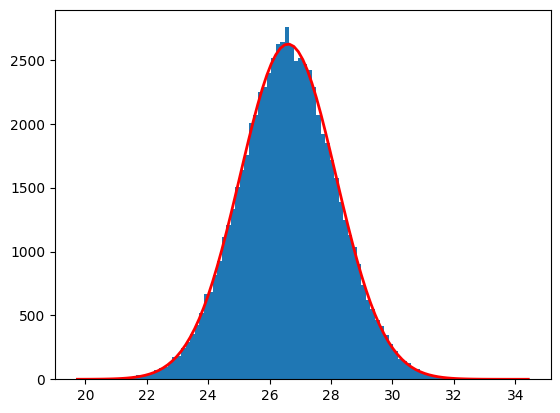

In [25]:
import matplotlib.pyplot as plt
count, bins, _ = plt.hist(test, 100, density=False)
A=(bins[1]-bins[0])*N
plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (bins - mu)**2 / (2 * sigma**2) )*A, linewidth=2, color='r')
plt.show()


### Note

We adopt the functional form of Harris et al. (2009) for both detection and selection completeness. The selection function parameters are calibrated to reproduce the empirically reported fractions of detected sources classified as GC candidates in Madrid et al. (2018).


In [26]:
import numpy as np

def harris_completeness(m, m0, alpha):
    """
    Harris/Madrid completeness curve.
    Returns probability in [0,1] for each magnitude m.
    """
    m = np.asarray(m, dtype=float)
    x = alpha * (m - m0)
    return 0.5 * (1.0 - x / np.sqrt(1.0 + x*x))

def apply_detection_and_selection(m814, rng,
                                 det_params=(27.62, 0.48),
                                 sel_params=(25.08, 1.2)):  # was 25.8 and 1.35 from Madrid+2018, but calibration adjusted
    """
    Apply two-stage thinning:
      detected ~ Bernoulli(p_det(m))
      selected ~ Bernoulli(p_sel(m)) conditional on detected

    Returns:
      detected (bool array)
      selected (bool array)   # subset of detected
      p_det, p_sel (float arrays)
    """
    m814 = np.asarray(m814, dtype=float)

    m0_det, a_det = det_params
    m0_sel, a_sel = sel_params

    p_det = harris_completeness(m814, m0_det, a_det)
    p_sel = harris_completeness(m814, m0_sel, a_sel)  # P(selected | detected, m)

    detected = rng.random(m814.size) < p_det

    selected = np.zeros(m814.size, dtype=bool)
    # Only draw selection for detected sources
    idx = np.where(detected)[0]
    if idx.size:
        selected[idx] = rng.random(idx.size) < p_sel[idx]

    return detected, selected, p_det, p_sel


In [27]:
data.columns

Index(['x_wcs', 'y_wcs', 'flux_814', 'flux_475', 'mag_814', 'mag_475', 'color',
       'pointing', 'x', 'y', 'type', 'x_wcs_f', 'y_wcs_f', 'gc_type_f',
       'pointing_f', 'Unnamed: 15'],
      dtype='object')

1561.0 3185.0 0.4901098901098901


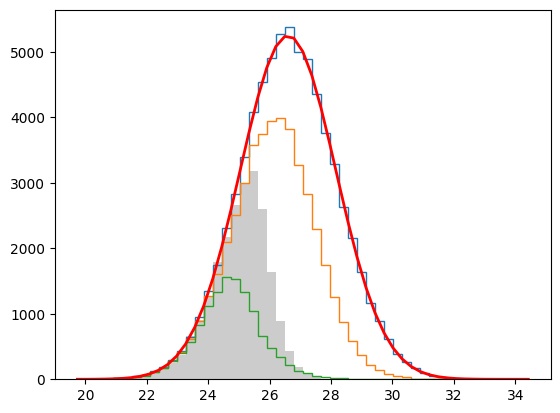

In [28]:
detected, selected, p_det, p_sel = apply_detection_and_selection(test, rng)

m814_detected = test[detected]
m814_selected = test[selected]   # this is the “GC candidate catalog”

count, bins, _ = plt.hist(test, 50, density=False, histtype='step')
count_det, _ , _ = plt.hist(m814_detected, bins, density=False, histtype='step')
count_sel, _ , _ = plt.hist(m814_selected, bins, density=False, histtype='step')
count_obs, _ , _ = plt.hist(data['mag_814'], bins, density=False, color='black', alpha=0.2)
A=(bins[1]-bins[0])*N
print(np.max(count_sel), np.max(count_obs), np.max(count_sel) / np.max(count_obs))
plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (bins - mu)**2 / (2 * sigma**2) )*A, linewidth=2, color='r')
plt.show()


In [29]:
for mtest in [23.0, 24.0, 25.0, 26.0]:
    print(mtest, apply_detection_and_selection([mtest], rng))


23.0 (array([ True]), array([ True]), array([0.95580063]), array([0.96413568]))
24.0 (array([ True]), array([ True]), array([0.93335828]), array([0.89585736]))
25.0 (array([False]), array([False]), array([0.89135565]), array([0.54778033]))
26.0 (array([ True]), array([False]), array([0.80692658]), array([0.12942302]))


In [30]:
assert np.all(selected <= detected)


In [216]:
# Old simulate routine
def simulate_css_around_sats(objects_list, simulate, n, r_within_factor):
    """
    Simulate CSS positions clustered around a list of satellites.

    Parameters
    ----------
    objects_list : list of galaxies
        name, RA, Dec, show_label.

    Returns
    -------
    pandas.DataFrame with columns ['ra', 'dec', 'satellite_index']
    """
    logger.debug(f'Simulating CSS population around galaxies')
   
    rows = []
    
    for i, galaxy in enumerate(objects_list):
        name = galaxy[0]
        if name == 'Coma cluster':
            continue

        gal_row = gals_df.loc[gals_df['name'] == name].iloc[0]
        Re_arcsec = 5 if (np.isnan(gal_row['Re_arcsec'])) else gal_row['Re_arcsec']  # set 5 arcsec as Re if numpy nan
        MV = gal_row['MV']
        n_per_sat = get_GCcount(MV).astype(int)
        # if i==0:
        #     logger.debug(f'{galaxy}: Re-{Re_arcsec}, Ncss-{n_per_sat}')
        scale_arcsec = Re_arcsec * 8
        sat = SkyCoord(galaxy[1]*u.deg, galaxy[2]*u.deg)

        # area_square = (2*r_max)**2
    
        simulated = 0
        # build an Offset frame around each sat
        offset_frame = SkyOffsetFrame(origin=sat)

        if simulate == 'exp': 
            # draw random offsets in a 2D radial exponential distribution (arcsec)
            # 1) draw radial distances r ~ Exponential(scale=λ)
            r = np.random.exponential(scale_arcsec, size=n_per_sat) * u.arcsec
        elif simulate == 'sersic':
            # draw radial distances from n Sérsic
            # r, n_per_sat_full = sample_sersic_radii_truncated(n_per_sat,  Re_arcsec=Re_arcsec, r_within_factor=r_within_factor, n=n) 
            r = sample_sersic_radii(N=n_per_sat, Re=r_within_factor, n=n)  # R_max=None, rng=None
            r = Re_arcsec * r * u.arcsec 
            # sample_sersic_radii(re_arcsec=r_max, n=n, size=n_per_sat) * u.arcsec
        else:
            raise ('Simulate should be None, "exp" or "sersic".')

        # logger.debug(f'{name:>25} - Sérsic Re: {r_max_factor:>5.1f}, R_trunc: {r_max_factor*Re_arcsec:5.1f}, CSS N_re: {n_per_sat:<5d}, Full: {n_per_sat_full:<5d}')
        
        # random angles θ uniform [0,2π)
        theta = np.random.uniform(0, 2*np.pi, size=n_per_sat) * u.rad  # was n_per_sat_full

        # convert polar offsets to dx, dy
        dx = r * np.cos(theta)
        dy = r * np.sin(theta)

        # create offset coords and transform back to ICRS
        offset_coords = SkyCoord(lon=dx, lat=dy, frame=offset_frame)
        world_coords = offset_coords.transform_to('icrs')

        # collect
        for w in world_coords:
            rows.append({
                'x_wcs': w.ra.deg,
                'y_wcs': w.dec.deg,
                'satellite_index': i, 'pad': False
            })

    return pd.DataFrame(rows)



In [31]:
import numpy as np
from typing import Iterable, Tuple, Optional


def assign_colors_piecewise(
    mag814: np.ndarray,
    rng: np.random.Generator,
    *,
    # Bright regime (single Gaussian)
    bright_mag_cut: float = 23.0,
    bright_mu: float = 1.72,
    bright_sigma: float = 0.24,
    # Mid regime (binned 2-Gaussian mixture)
    mag_edges: Tuple[float, ...] = (23.0, 24.0, 25.0, 26.0, 27.0),
    # per-bin tuples: (mu_b, sigma_b, mu_r, sigma_r, w_b)
    gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
        (1.58, 0.30, 1.76, 0.19, 0.54),  # 23-24
        (1.51, 0.15, 1.68, 0.23, 0.59),  # 24-25
        (1.46, 0.18, 1.67, 0.25, 0.55),  # 25-26
        (1.40, 0.22, 1.64, 0.28, 0.57),  # 26-27
    ),
    # Faint regime handling
    faint_mode: str = "extend",  # "extend" or "clamp"
    faint_max_edge: float = 28.0,  # used only if faint_mode=="extend"
    # Color window handling
    color_min: float = 0.5,
    color_max: float = 2.5,
    enforce_color_window: bool = True,
    resample_oob: bool = True,
    max_resample_iter: int = 12,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Assign (F475W - F814W) colors using a piecewise model:
      - For mag < bright_mag_cut: single Gaussian N(bright_mu, bright_sigma)
      - For bright_mag_cut <= mag < last_edge: mag-binned 2-Gaussian mixture
      - For mag >= last_edge: either clamp to last bin ("clamp") or extend edges
        and reuse last-bin params up to faint_max_edge ("extend")

    Parameters
    ----------
    mag814 : array-like
        F814W magnitudes of objects (typically your selected mock catalog).
    rng : np.random.Generator
        Numpy random generator for reproducibility.
    bright_mag_cut : float
        Bright-end cutoff where bimodality is treated as merged.
    bright_mu, bright_sigma : float
        Parameters of the single-Gaussian bright-end color model.
    mag_edges : tuple
        Bin edges for the bimodal regime (must be increasing; first edge should
        typically equal bright_mag_cut).
    gmm_params : tuple of tuples
        One (mu_b, sigma_b, mu_r, sigma_r, w_b) per bin defined by mag_edges.
    faint_mode : {"extend","clamp"}
        - "clamp": mags >= last_edge use the last bin's params
        - "extend": add an extra bin [last_edge, faint_max_edge) reusing last params
    faint_max_edge : float
        Upper edge for the extended faint bin (ignored if faint_mode=="clamp").
    enforce_color_window : bool
        Whether to enforce the [color_min, color_max] window.
    resample_oob : bool
        If True, resample out-of-bounds colors up to max_resample_iter; else clip.
    max_resample_iter : int
        Max resampling iterations for out-of-bounds values.

    Returns
    -------
    color : (N,) ndarray
        Simulated colors (F475W - F814W).
    is_blue_true : (N,) ndarray
        True component label for mid-regime mixture:
          - True for blue component
          - False for red component
          - np.nan for bright-regime (single Gaussian, no subpop defined)
    mag_bin_id : (N,) ndarray
        Integer bin id for the mid-regime bins. For bright-regime returns -1.
        For faint-regime returns the last bin id (or extended id if used).

    Notes
    -----
    - This function is designed for *simulation*, not fitting.
    - The bright regime is intentionally single-Gaussian to avoid unstable
      bimodal inference in the UCD-adjacent magnitude range.
    """
    mag814 = np.asarray(mag814, dtype=float)
    N = mag814.size

    edges = np.asarray(mag_edges, dtype=float)
    if edges.ndim != 1 or edges.size < 2:
        raise ValueError("mag_edges must be a 1D tuple/array with >=2 elements.")
    if not np.all(np.diff(edges) > 0):
        raise ValueError("mag_edges must be strictly increasing.")
    nbins = edges.size - 1

    if len(gmm_params) != nbins:
        raise ValueError(
            f"gmm_params length ({len(gmm_params)}) must match number of bins ({nbins})."
        )

    # Optionally extend faint edge with an extra bin reusing last params
    params = np.array(gmm_params, dtype=float)  # shape (nbins, 5)
    if faint_mode not in ("extend", "clamp"):
        raise ValueError('faint_mode must be either "extend" or "clamp".')

    if faint_mode == "extend":
        if faint_max_edge <= edges[-1]:
            raise ValueError("faint_max_edge must be > mag_edges[-1] when faint_mode='extend'.")
        # Add extra bin at the faint end using last bin params
        edges_ext = np.concatenate([edges, [float(faint_max_edge)]])
        params_ext = np.vstack([params, params[-1:]])
        edges = edges_ext
        params = params_ext
        nbins = edges.size - 1

    # Initialize outputs
    color = np.empty(N, dtype=float)
    # use float dtype so we can store np.nan for bright regime
    is_blue_true = np.full(N, np.nan, dtype=float)
    mag_bin_id = np.full(N, -1, dtype=int)

    # Masks
    bright = mag814 < bright_mag_cut
    mid_or_faint = ~bright

    # -------- Bright regime: single Gaussian --------
    if np.any(bright):
        color[bright] = rng.normal(loc=bright_mu, scale=bright_sigma, size=int(bright.sum()))
        # is_blue_true stays np.nan; mag_bin_id stays -1

    # -------- Mid/Faint regime: mixture by mag bin --------
    if np.any(mid_or_faint):
        m = mag814[mid_or_faint]

        # Bin assignment for mixture regime
        # digitize returns:
        #   edge[0] <= m < edge[1] -> 1
        # so subtract 1 to get 0-indexed bin id
        bin_id = np.digitize(m, edges) - 1

        # Handle out-of-range magnitudes
        if faint_mode == "clamp":
            # Clamp everything outside edges to nearest valid bin (mainly affects >edges[-1])
            bin_id = np.clip(bin_id, 0, nbins - 1)
        else:
            # With 'extend', edges already include faint_max_edge, so clamp just in case
            bin_id = np.clip(bin_id, 0, nbins - 1)

        # Store bin ids in full output
        mag_bin_id[mid_or_faint] = bin_id

        # Build per-object parameter arrays
        mu_b = params[bin_id, 0]
        sg_b = params[bin_id, 1]
        mu_r = params[bin_id, 2]
        sg_r = params[bin_id, 3]
        w_b  = params[bin_id, 4]

        # Draw mixture component
        u = rng.random(size=m.size)
        is_blue = u < w_b

        # Draw colors
        c = np.empty(m.size, dtype=float)
        nb = int(is_blue.sum())
        nr = int(m.size - nb)
        if nb:
            c[is_blue] = rng.normal(loc=mu_b[is_blue], scale=sg_b[is_blue], size=nb)
        if nr:
            c[~is_blue] = rng.normal(loc=mu_r[~is_blue], scale=sg_r[~is_blue], size=nr)

        # Write back to full arrays
        color[mid_or_faint] = c
        # Store component label (as float 1.0/0.0 for easy grouping; cast later if desired)
        is_blue_true[mid_or_faint] = is_blue.astype(float)

    # -------- Enforce color window (optional) --------
    if enforce_color_window:
        if resample_oob:
            # We can resample BOTH regimes; for bright regime we use bright Gaussian,
            # for mixture regime we resample within their assigned component.
            for _ in range(max_resample_iter):
                oob = (color < color_min) | (color > color_max)
                if not np.any(oob):
                    break

                # Bright subset resample
                oob_bright = oob & bright
                if np.any(oob_bright):
                    color[oob_bright] = rng.normal(
                        loc=bright_mu, scale=bright_sigma, size=int(oob_bright.sum())
                    )

                # Mid/faint subset resample (preserve assigned component)
                oob_mid = oob & (~bright)
                if np.any(oob_mid):
                    # retrieve their bin ids and component labels
                    b = mag_bin_id[oob_mid]
                    mu_b = params[b, 0]
                    sg_b = params[b, 1]
                    mu_r = params[b, 2]
                    sg_r = params[b, 3]
                    # is_blue_true is 1.0/0.0 here
                    isb = is_blue_true[oob_mid] > 0.5
                    if np.any(isb):
                        color[oob_mid][isb] = rng.normal(
                            loc=mu_b[isb], scale=sg_b[isb], size=int(isb.sum())
                        )
                    if np.any(~isb):
                        color[oob_mid][~isb] = rng.normal(
                            loc=mu_r[~isb], scale=sg_r[~isb], size=int((~isb).sum())
                        )

            # Final safety clip (rarely needed)
            np.clip(color, color_min, color_max, out=color)
        else:
            np.clip(color, color_min, color_max, out=color)

    return color, is_blue_true, mag_bin_id


In [160]:
data

,x_wcs,y_wcs,flux_814,flux_475,mag_814,mag_475,color,pointing,x,y,type,x_wcs_f,y_wcs_f,gc_type_f,pointing_f,Unnamed: 15
0,194.09794,27.244074,0.458373,0.203884,26.152547,27.681062,1.528516,OS21,708.977,3994.384,gc,194.09794,27.244074,gc,OS21,NaN
1,194.09828,27.212645,1.207550,1.165456,25.100832,25.788280,0.687449,OS21,2964.827,4170.375,gc,194.09828,27.212645,gc,OS21,NaN
3,194.09916,27.222516,4.788598,2.630347,23.605074,24.904488,1.299414,OS21,2261.617,4052.017,gc,194.09916,27.222516,gc,OS21,NaN
4,194.09917,27.213105,4.268017,1.134324,23.730029,25.817677,2.087648,OS21,2937.748,4109.924,gc,194.09917,27.213105,gc,OS21,NaN
5,194.09971,27.207500,2.269763,2.564432,24.415643,24.932042,0.516399,OS21,3342.696,4111.336,gc,194.09971,27.207500,gc,OS21,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23346,195.28033,28.038643,4.178208,1.721223,23.753119,25.364927,1.611808,2-0,459.481,524.648,gc,195.28033,28.038643,gc,2-0,NaN
23347,195.28280,28.033002,0.981487,0.369114,25.325883,27.036618,1.710735,2-0,749.952,200.419,gc,195.28280,28.033002,gc,2-0,NaN
23348,195.28426,28.034550,3.065800,1.159595,24.089235,25.793754,1.704519,2-0,608.576,168.534,gc,195.28426,28.034550,gc,2-0,NaN
23349,195.28566,28.036739,2.104311,0.830435,24.497820,26.156256,1.658436,2-0,427.637,160.580,gc,195.28566,28.036739,gc,2-0,NaN


In [54]:
    
def simulate_css_around_sats_GCRe(objects_list, p): # simulate, n, cf=1.0):
    """
    Simulate CSS positions clustered around a list of satellites.
    As above routine, but this uses Re_GCS_arcsec which has been calculated from 
    SDSS data (DR17)

    Parameters
    ----------
    objects_list : list of galaxies
        name, RA, Dec, show_label.

    Returns
    -------
    pandas.DataFrame with columns ['ra', 'dec', 'satellite_index']
    """
    
    logger.debug(f'Simulating CSS population around galaxies with GC Re from archives')
    simulate = p.simulate
    n = p.Se_n
    cf = p.cf
    logger.debug(f'Completeness fraction: {cf}')
    rows = []

    for i, galaxy in enumerate(objects_list):
        name = galaxy[0]
        if name == 'Coma cluster':
            continue
        index_n = n-0.2 if name in ['NGC 4889', 'NGC 4874'] else n

        gal_row = gals_df.loc[gals_df['name'] == name].iloc[0]
        Re_GCS_arcsec = 1 if (np.isnan(gal_row['Re_GCS_arcsec'])) else gal_row['Re_GCS_arcsec']  # set 1 arcsec as Re if numpy nan - only 8 at last count
        MV = gal_row['MV']
        n_per_sat = get_GCcount(MV).astype(int)
        # if i==0:
        #     logger.debug(f'{galaxy}: Re-{Re_arcsec}, Ncss-{n_per_sat}')
        sat = SkyCoord(galaxy[1]*u.deg, galaxy[2]*u.deg)

        # area_square = (2*r_max)**2
    
        simulated = 0
        # build an Offset frame around each sat
        offset_frame = SkyOffsetFrame(origin=sat)

        if simulate == 'exp': 
            # draw random offsets in a 2D radial exponential distribution (arcsec)
            # 1) draw radial distances r ~ Exponential(scale=λ)
            r = np.random.exponential(Re_GCS_arcsec, size=n_per_sat) * u.arcsec
        elif simulate == 'sersic':
            # draw radial distances from n Sérsic
            # r, n_per_sat_full = sample_sersic_radii_truncated(n_per_sat,  Re_arcsec=Re_arcsec, r_within_factor=r_within_factor, n=n) 
            r = sample_sersic_radii(N=n_per_sat, Re=Re_GCS_arcsec, n=index_n)  # R_max=None, rng=None
            r = r * u.arcsec 
            # sample_sersic_radii(re_arcsec=r_max, n=n, size=n_per_sat) * u.arcsec
        else:
            raise ('Simulate should be None, "exp" or "sersic".')

        # logger.debug(f'{name:>25} - Sérsic Re: {r_max_factor:>5.1f}, R_trunc: {r_max_factor*Re_arcsec:5.1f}, CSS N_re: {n_per_sat:<5d}, Full: {n_per_sat_full:<5d}')
        
        # random angles θ uniform [0,2π)
        theta = np.random.uniform(0, 2*np.pi, size=n_per_sat) * u.rad  # was n_per_sat_full

        # convert polar offsets to dx, dy
        dx = r * np.cos(theta)
        dy = r * np.sin(theta)

        # create offset coords and transform back to ICRS
        offset_coords = SkyCoord(lon=dx, lat=dy, frame=offset_frame)
        world_coords = offset_coords.transform_to('icrs')

        # Vectorise - Convert world_coords to arrays
        ra = world_coords.ra.deg
        dec = world_coords.dec.deg

        # draw GC mags from intrinsic GCLF - NO radial dependence at this stage
        mag814 = draw_gclf_mags(p.gclf_mu, p.gclf_sigma, n_per_sat, p.gclf_rng)
        detected, selected, p_det, p_sel = apply_detection_and_selection(mag814, p.gclf_rng)

        # Keep only selected (final GC-candidate catalog)
        keep = selected
        
        df_gal = pd.DataFrame({
            'x_wcs': ra[keep],
            'y_wcs': dec[keep],
            'r_arcsec': r[keep],
            'r_GCS_re': r[keep]/Re_GCS_arcsec,
            'gal_name': name,
            'satellite_index': i,
            'mag814': mag814[keep],
            'detected': detected[keep],   # will all be True if keep==selected, but ok
            'selected': selected[keep],   # will all be True
            'p_det': p_det[keep],
            'p_sel': p_sel[keep],
            'pad': False
        })

        # Now add color sampling to 'selected' mock catalog with df["mag814"]
        colors, is_blue_true, mag_bin_id = assign_colors_piecewise(
            df_gal["mag814"].to_numpy(),
            rng=p.gclf_rng,
            bright_mag_cut=23.0,
            bright_mu=1.72,
            bright_sigma=0.24,
            faint_mode="extend",
            faint_max_edge=28.0,
        )
        
        df_gal["color_475_814"] = colors
        df_gal["is_blue_true"] = is_blue_true  # 1.0, 0.0, or nan for bright regime
        df_gal["gmm_mag_bin"] = mag_bin_id

        rows.append(df_gal)

    return pd.concat(rows, ignore_index=True)



In [33]:
import numpy as np
from typing import Tuple, Optional, Callable

def _normal_pdf(x: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    """Vectorized Normal PDF."""
    x = np.asarray(x, dtype=float)
    mu = np.asarray(mu, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (np.sqrt(2.0 * np.pi) * sigma)

def compute_Pblue(
    mag814: np.ndarray,
    color: np.ndarray,
    *,
    bright_mag_cut: float = 23.0,
    # mag-binned mixture model for >= bright_mag_cut
    mag_edges: Tuple[float, ...] = (23.0, 24.0, 25.0, 26.0, 27.0),
    gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
        (1.58, 0.30, 1.76, 0.19, 0.54),  # 23-24
        (1.51, 0.15, 1.68, 0.23, 0.59),  # 24-25
        (1.46, 0.18, 1.67, 0.25, 0.55),  # 25-26
        (1.40, 0.22, 1.64, 0.28, 0.57),  # 26-27
    ),
    # faint handling
    faint_mode: str = "extend",   # "extend" or "clamp"
    faint_max_edge: float = 28.0, # used only if extend
    # optional prior modifier (later): fb(R) model
    # If provided, pass an array fb of shape (N,) OR provide fb_func(r) separately.
    fb: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute P(blue | color, mag) under a mag-binned 2-Gaussian mixture.

    Returns:
      Pblue (N,) float array
      mag_bin_id (N,) int array (bright regime -> -1)
    """
    mag814 = np.asarray(mag814, dtype=float)
    color = np.asarray(color, dtype=float)
    if mag814.shape != color.shape:
        raise ValueError("mag814 and color must have the same shape.")

    N = mag814.size
    Pblue = np.full(N, np.nan, dtype=float)
    mag_bin_id = np.full(N, -1, dtype=int)

    # Bright regime: undefined for bimodality by construction
    bright = mag814 < bright_mag_cut
    mid_or_faint = ~bright

    # Prepare edges/params with faint handling
    edges = np.asarray(mag_edges, dtype=float)
    if faint_mode not in ("extend", "clamp"):
        raise ValueError('faint_mode must be either "extend" or "clamp".')
    params = np.array(gmm_params, dtype=float)
    nbins = edges.size - 1
    if params.shape[0] != nbins:
        raise ValueError("gmm_params length must match len(mag_edges)-1.")

    if faint_mode == "extend":
        if faint_max_edge <= edges[-1]:
            raise ValueError("faint_max_edge must be > mag_edges[-1] when extend.")
        edges = np.concatenate([edges, [float(faint_max_edge)]])
        params = np.vstack([params, params[-1:]])
        nbins = edges.size - 1

    if np.any(mid_or_faint):
        m = mag814[mid_or_faint]
        c = color[mid_or_faint]

        bin_id = np.digitize(m, edges) - 1
        bin_id = np.clip(bin_id, 0, nbins - 1)

        mu_b = params[bin_id, 0]
        sg_b = params[bin_id, 1]
        mu_r = params[bin_id, 2]
        sg_r = params[bin_id, 3]
        w_b  = params[bin_id, 4]

        # Likelihood terms
        pb = w_b * _normal_pdf(c, mu_b, sg_b)
        pr = (1.0 - w_b) * _normal_pdf(c, mu_r, sg_r)

        # Optional prior modifier (later): replace w_b -> fb*w_b and (1-w_b)->(1-fb)*(1-w_b)?
        # For now, if fb is provided, treat it as a multiplicative reweighting of the mixture prior:
        if fb is not None:
            fb_arr = np.asarray(fb, dtype=float)
            if fb_arr.shape != mag814.shape:
                raise ValueError("fb must have the same shape as mag814/color if provided.")
            fb_sub = fb_arr[mid_or_faint]
            pb = fb_sub * pb
            pr = (1.0 - fb_sub) * pr

        denom = pb + pr
        # Safe division
        p = np.divide(pb, denom, out=np.full_like(pb, np.nan), where=denom > 0)

        Pblue[mid_or_faint] = p
        mag_bin_id[mid_or_faint] = bin_id

    return Pblue, mag_bin_id


In [251]:
# Another old 2d voronoi routine
from scipy.interpolate import griddata
import matplotlib.colors as colors
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.visualization.wcsaxes import WCSAxes
from astropy.visualization import (PercentileInterval, AsinhStretch, ImageNormalize)
from astropy.coordinates import SkyOffsetFrame, Angle

def calc_gal_2D_voronoi_profile(gal, satellites=None, k=7, min_radius=10, r_max_re=10,
                                r_annular=None, d_annular=None, popt=None, plot_ylim=(0,0.8),
                                pa_range_deg=(0,360), fn=None):

    font={'size':24.0}
    plt.rc('font', **font)

    print(fn)
    hdu = fits.open(fn)[0]
    wcs = WCS(hdu.header)
    image_data = hdu.data


    # fig, ax = plt.subplots(figsize=(16, 13), subplot_kw={'projection': wcs})

    # finite_data = image_data[np.isfinite(image_data)]

    # vmin = np.percentile(finite_data, 5)
    # vmax = np.percentile(finite_data, 99)
    # norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(0.6))
    # ax.imshow(image_data, origin='lower', cmap='gray_r', norm=norm)
    # plt.tight_layout()
    # plt.show()
    # plt.close()
    
    #     r_max_re=10
    gal_row = gals_df.loc[gals_df['name'] == gal].iloc[0]
    center_ra = gal_row['ra']
    center_dec = gal_row['dec']
    Re_arcsec = gal_row['Re_arcsec']

    r_max_arcsec = Re_arcsec * r_max_re
    grid_resolution=200
    log_scale=False

    center = SkyCoord(ra=center_ra*u.deg, dec=center_dec*u.deg)
    satellite_coords_re = get_sat_coords_and_Re(gals_df, satellites)

    sat_coords_re_sep = get_sat_seps(center, satellite_coords_re)

    df_k1, gal_profile_binned_df = compute_voronoi_density_profile(data, center_ra, center_dec, re_arcsec=Re_arcsec,
                                                          r_max_re=r_max_re, n_bins=16, pa_range_deg=pa_range_deg)
    
    df_k = merge_voronoi_cells(df_k1, k=k)

    x = df_k['x_arcsec'].values
    y = df_k['y_arcsec'].values
    density = df_k['density_per_arcsec2'].values

    # Interpolate to a grid
    grid_x, grid_y = np.mgrid[-r_max_arcsec:r_max_arcsec:grid_resolution*1j,
                              -r_max_arcsec:r_max_arcsec:grid_resolution*1j]
    grid_density = griddata((x, y), density, (grid_x, grid_y), method='cubic')

    print(np.isnan(grid_density).sum(), "NaNs out of", grid_density.size)

    fig, ax = plt.subplots(figsize=(16, 13))
    if log_scale:
        from matplotlib.colors import LogNorm
        im = ax.imshow(grid_density.T, origin='lower', alpha=0.5,
                       extent=[-r_max_arcsec, r_max_arcsec, -r_max_arcsec, r_max_arcsec],
                       cmap='viridis', norm=LogNorm(vmin=np.nanmin(grid_density[grid_density > 0]),
                                                    vmax=np.nanmax(grid_density)))
    else:
        im = ax.imshow(grid_density.T, origin='lower', alpha=0.5,
                       extent=[-r_max_arcsec, r_max_arcsec, -r_max_arcsec, r_max_arcsec],
                       cmap='viridis')

    cb = fig.colorbar(im, ax=ax, label=r'$\Sigma$ [arcsec$^{-2}$]')

    # Contours
    if log_scale:
        from matplotlib.colors import LogNorm
        levels = np.logspace(np.log10(np.nanmin(grid_density[grid_density > 0])),
                             np.log10(np.nanmax(grid_density)), 7)
    else:
        levels = np.linspace(np.nanmin(grid_density), np.nanmax(grid_density), 7)

    # contours = ax.contour(grid_x, grid_y, grid_density, levels=levels, colors='white', linewidths=1)
    contours = ax.contour(grid_x, grid_y, grid_density, levels=levels, cmap='viridis', linewidths=1)
    ax.clabel(contours, inline=True, fontsize=10, fmt="%.3f")

    # Circle showing max radius
    circle = plt.Circle((0, 0), Re_arcsec * 8, color='gray', linestyle='--', fill=False, lw=1.5)
    ax.add_patch(circle)

    max_arcsec = r_max_arcsec/np.sqrt(2)

    ax.set_xlabel('X [arcsec]')
    ax.set_ylabel('Y [arcsec]')
    ax.set_title('2D CSS Density Map (Voronoi-derived)')
    ax.set_aspect('equal')
    ax.set_xlim(max_arcsec, -max_arcsec)
    ax.set_ylim(-max_arcsec, max_arcsec)
    plt.tight_layout()
    plt.show()    
    
    return df_k



In [34]:
import os
from glob import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from matplotlib.patches import Polygon as Poly
from reproject import reproject_interp
from astropy.visualization import AsinhStretch, ImageNormalize


def extract_filter(hdr):
    """
    Return the science filter from HST FITS header.
    Prefer FILTER2 if FILTER1 is CLEAR or vice versa.
    """
    f1 = hdr.get('FILTER1', '').strip().upper()
    f2 = hdr.get('FILTER2', '').strip().upper()

    # If either is CLEAR, return the other
    if 'CLEAR' in f1:
        return f2
    elif 'CLEAR' in f2:
        return f1
    else:
        # Default: return FILTER2 if both are populated
        return f2 or f1

    
def plot_fits_outlines(base_dir, ax, bg_wcs, filter_key='F814W'):

    bg_shape = [[0,0],[0,0]]

    bg_shape[1] = ax.get_xlim()
    bg_shape[0] = ax.get_ylim()

    # logger.debug(f'Background shape: x-{bg_shape[1]}, y-{bg_shape[0]}')
    
    # Search recursively for FITS files
    all_fits = sorted(glob(os.path.join(base_dir, '**', '*.fits'), recursive=True), key=str.lower)
    
    excluded_regions = ['/OS17/', '/OS21/', '3-5/jb2','OS3', 'OS4', '/7-7/', 'OS13'] 
    for path in all_fits:
        if any(region in path for region in excluded_regions):  # → True / False
            continue 

        try:
            with fits.open(path) as hdul:
                hdr = hdul[0].header
                # Try to extract filter name from common header keywords
                filter_name = extract_filter(hdr)
                if filter_name is None or filter_key.upper() not in filter_name:
#                     print(f'{filter_key} not found in {path}: Got {filter_name}')
                    continue
                # print(f'{filter_key} found in {path}: Got {filter_name}')
                hdr = hdul[1].header
                data = hdul[1].data
                w = WCS(hdr)
                ny, nx = data.shape

                # Define corners of the image in pixel space
                corners_pix = np.array([[0, 0], [0, ny], [nx, ny], [nx, 0]])
                # logger.debug(f'Corners (wcs pix): {corners_pix}')

                # Convert to sky (RA/Dec)
                corners_world = w.pixel_to_world(corners_pix[:, 0], corners_pix[:, 1])
                # Convert to background WCS pixel coords
                sky_coords = SkyCoord(corners_world)
                bg_x, bg_y = bg_wcs.world_to_pixel(sky_coords)
                # logger.debug(f'Corners (bg pix): {bg_x}, {bg_y}')
                
                # Skip if all corners are outside the background image
                within_x = (bg_x >= bg_shape[1][1]) & (bg_x <= bg_shape[1][0])
                within_y = (bg_y >= bg_shape[0][0]) & (bg_y <= bg_shape[0][1])
                visible = np.any(within_x & within_y)
                if not visible:
                    continue

                polygon = np.column_stack([bg_x, bg_y])
                
                filename = os.path.basename(path)
                if 'F814W' in filename:
                    edge_color = 'blue'
                    text_color = 'darkblue'
                elif 'jc' in filename:
                    edge_color = 'green'
                    text_color = 'darkgreen'
                elif 'jb' in filename:
                    edge_color = 'purple'
                    text_color = 'magenta'
                else:
                    edge_color = 'orange'
                    text_color = 'darkorange'

                edge_color = 'green'      # in the end, only set to green - no pointing color differences 
                text_color = 'darkgreen'  # comment out these lines if color distinguishing required.
                    
                # Get label from subdirectory name
                label = Path(path).parent.name
                poly = Poly(polygon, closed=True, fill=False, edgecolor=edge_color, lw=1.5, alpha=0.4, label=label)
                ax.add_patch(poly)
                
#                 plot_objects(194.8938896, 27.9016579, bg_wcs, ax)
                
#                 # Place text near one corner
#                 ax.text(bg_x[0], bg_y[0], label, color=edge_color)
                # Compute center of the polygon in pixel coordinates
                text_x = np.mean(bg_x)
                text_y = np.mean(bg_y)
                if (bg_shape[1][1] <= text_x <= bg_shape[1][0]) and (bg_shape[0][0] <= text_y <= bg_shape[0][1]):
                    ax.text(text_x, text_y, label, color=text_color, ha='center', va='center')

        except Exception as e:
            logging.warning(f"Skipping {path}: {e}")
            continue

    

In [35]:

from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import AsinhStretch, ImageNormalize
from astropy.visualization import PercentileInterval
from astropy.visualization.wcsaxes import SphericalCircle
from astropy.visualization.wcsaxes.formatter_locator import AngleFormatterLocator
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize, ListedColormap, BoundaryNorm, LogNorm, LinearSegmentedColormap, TwoSlopeNorm
from matplotlib import colormaps
from matplotlib import ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numbers
from collections.abc import Sequence

from matplotlib.ticker import FuncFormatter
from scipy.interpolate import griddata, CloughTocher2DInterpolator
import numpy as np
from scipy.spatial import Delaunay
import pickle

###############################################################################################################
# Define dataclass of parameters to pass between separated calculation and plot functions
###############################################################################################################
from dataclasses import dataclass, field, asdict, fields, replace
from pathlib import Path

@dataclass
class ProfileParams:
    gal: str
    satellites: list = None
    r_max_re: int = 30
    k: int = 5
    grid_resolution: int = 300
    plot_size: int = 450
    simulate: str = None
    results: str = None
    realizations: int = 1
    Se_n: float = 0.55
    Se_Re: float = 4.
    Se_Re_arcsec: float = 4.
    cf: float = 1.0                                     # CF Changed from 0.35 to 1.0, to account for GCLF in color script adaptation
    log_scale: bool = False
    wcs: WCS = None
    center_ra: float = 195.
    center_dec: float = 28.
    pa_range_deg: tuple[float, float] = (0., 360.)
    Re_arcsec: float = 5.
    image_data: np.ndarray = None
    image_cmap: str = 'gray_r'
    show_background_image: bool = True
    show_pointing_outlines: bool = False
    grid_density: np.ndarray = None
    grid_density_std: np.ndarray = None
    grid_interpolation: str = 'linear'
    extent: list[float, float, float, float] = None
    df_k: pd.DataFrame = None
    sigma_smoothing: int = None
    gclf_mu: float = 26.6
    gclf_sigma: float = 1.562
    gclf_rng: np.random.Generator = field(default=None)

    def __post_init__(self):
        if self.gclf_rng is None:
            self.gclf_rng = np.random.default_rng()
    
    @classmethod
    def load(cls, path: Path, *, gal: str) -> "ProfileParams":
        rng = np.random.default_rng(seed=42)
        default = cls(gal=gal, gclf_rng=rng)  # run defaults/default_factory with the required arg
        try:
            return pickle.loads(path.read_bytes())
        except FileNotFoundError:
            return default
        except Exception:
            return default

    def save(self, path: Path) -> None:
        path.parent.mkdir(parents=True, exist_ok=True)
        tmp = path.with_suffix(path.suffix + ".tmp")
        tmp.write_bytes(pickle.dumps(self))
        tmp.replace(path)

    

In [36]:
###############################################################################################################
# start of calculation section
###############################################################################################################
# def calc_gal_2D_voronoi_profile_w_fits(params,
#     gal, satellites=None, k=7, r_max_re=10,
#     pa_range_deg=(0, 360), fn=None, grid_resolution = 300,
#     simulate=None, Se_n=0.6, Se_Re=4.8
# ):
def calc_gal_2D_voronoi_profile_w_fits(params, fn):
    
    def grid_counts(res):
        """
        Accepts an int/float (square) or a 2-tuple/list/array (Nx, Ny).
        Returns (Nx, Ny) as positive ints.
        """
        # logger.debug('Extracting grid resolution')
        if isinstance(res, numbers.Integral):
            Ny = Nx = int(res)
        elif isinstance(res, numbers.Real) and float(res).is_integer():
            Ny = Nx = int(res)
        elif isinstance(res, Sequence) and not isinstance(res, (str, bytes)):
            if len(res) != 2:
                raise ValueError("grid_resolution sequence must have length 2 (Nx, Ny).")
            Nx, Ny = (int(round(res[0])), int(round(res[1])))
        else:
            raise TypeError("grid_resolution must be int/float or a (Nx, Ny) pair.")
    
        if Nx <= 0 or Ny <= 0:
            raise ValueError("Ny and Nx must be positive.")
        return Nx, Ny

    def calc_grid_density():
        logger.debug('Computing Voronoi profile (k=1)')

        df_k1, gal_profile_binned_df = compute_voronoi_density_profile_full(
            css_df, params.center_ra, params.center_dec, re_arcsec=2000,
            r_max_re=4, n_bins=16, pa_range_deg=params.pa_range_deg
        )
        if params.k!=1:
            logger.debug(f'Computing Voronoi profile (k={params.k})')
            params.df_k = merge_voronoi_cells(df_k1, k=params.k)
        else:
            params.df_k = df_k1
    
        # Convert x/y arcsec to RA/Dec
        x_offset_deg = (params.df_k['x_arcsec'].values * u.arcsec).to(u.deg).value
        y_offset_deg = (params.df_k['y_arcsec'].values * u.arcsec).to(u.deg).value
        ra_vals = center.ra.deg + x_offset_deg / np.cos(center.dec.radian)
        dec_vals = center.dec.deg + y_offset_deg
    
        # Interpolate to grid
        logger.debug(f'Interpolating grid')
        
        density = params.df_k['density_per_arcsec2'].values 
        params.grid_density = griddata((ra_vals, dec_vals), density, (grid_ra, grid_dec), 
                                method=params.grid_interpolation, fill_value=np.nan)  # interpolate the density values to the grid

        err_density = params.df_k['err_density'].values
        err_density = np.clip(err_density, 0, None)  # enforce non-negative per-cell errors
        params.grid_density_std = griddata((ra_vals, dec_vals), err_density, (grid_ra, grid_dec), 
                                            method='nearest', fill_value=np.nan)  # also the 1-sigma poisson uncertainty values to same grid
    
        params.grid_density = np.clip(params.grid_density, a_min=0, a_max=None)
        # produce a mask of where grid_density is finite:
        mask = np.isfinite(params.grid_density)

    Nx, Ny = grid_counts(params.grid_resolution)

    logger.info('')
    if archive:
        logger.warning('NOTE: Using SIMBAD / NED extracted data for Coma cluster galaxies')
    else:
        logger.warning('NOTE: Using manual data for Coma cluster galaxies')
    logger.info(f'Calculating 2D Voronoi profile for {params.gal}, with satellites.')
    logger.info(f'Voronoi tesselation k={params.k} with {params.grid_interpolation} interpolation over a {Nx}x{Ny} grid.')
    logger.info(f'Note the SIMULATE flag is set to {params.simulate}')
    if params.simulate=='sersic':
        logger.info(f'for the Sérsic simulation, the index n={params.Se_n}, and the effective radius Re={params.Se_Re}.')
    logger.info('')

    # Load FITS image and WCS
    logger.debug(f'Loading {fn}')
    hdu = fits.open(fn)[0]
    params.wcs = WCS(hdu.header)
    params.image_data = hdu.data

    # Galaxy info
    logger.debug(f'Getting galaxy info for {params.gal}')
    gal_row = gals_df.loc[gals_df['name'] == params.gal].iloc[0]
    params.center_ra = gal_row['ra']
    params.center_dec = gal_row['dec']
    params.Re_arcsec = gal_row['Re_arcsec']
    params.Se_Re_arcsec = gal_row['Re_GCS_arcsec']

    center = SkyCoord(ra=params.center_ra * u.deg, dec=params.center_dec * u.deg)
    logger.debug(f'Galaxy {params.gal} located at {center}, effective radius {params.Re_arcsec}')

    # Radius and plotting setup
    r_max_arcsec = params.Re_arcsec * params.r_max_re
    r_max_arcsec = 1100
    radius_deg = (r_max_arcsec * u.arcsec).to(u.deg).value
    
    # RA/Dec limits (accounting for RA convergence)
    logger.debug(f'Setting RA/Dec limits')
    ra_min = center.ra.deg - radius_deg / np.cos(center.dec.radian)
    ra_max = center.ra.deg + radius_deg / np.cos(center.dec.radian)
    dec_min = center.dec.deg - radius_deg
    dec_max = center.dec.deg + radius_deg
    
    logger.debug(f'Plotting to center RA±{(radius_deg / np.cos(center.dec.radian)*u.deg).to(u.arcsec).value:.1f}, Dec±{(radius_deg*u.deg).to(u.arcsec).value:.1f}')
    params.extent=[ra_min, ra_max, dec_min, dec_max]
    # create grid and distance
    grid_dec, grid_ra = np.mgrid[
        dec_min:dec_max:Ny*1j,
        ra_min:ra_max:Nx*1j
    ]
    # Now we have grid RA and Dec, we calculate a boolean mask for grid points inside the pointing footprints
    logger.debug(f'Creating pointing mask from HST/ACS footprints')
    in_pointings = build_footprint_mask(footprint_pointings, grid_ra, grid_dec, center_ra=194.953)

    objects_list = [[name, *gals_df.loc[gals_df['name'] == name, ['ra', 'dec', 'show_label']].values[0]] for name in params.satellites]

    if objects_list is not None and params.simulate is not None:
        grid_stack = np.empty((params.realizations, Ny, Nx))
        for i in range(params.realizations):
            logger.debug(f'Simulation run: {i+1} of {params.realizations}')
            css_df = simulate_css_around_sats_GCRe(objects_list, params) # params.simulate, params.Se_n, params.cf)

            calc_grid_density()
            # Add background only inside footprint (so no fake std outside):
            grid = params.grid_density.copy()
            grid = np.where(in_pointings, params.grid_density, np.nan)
            grid = np.where(in_pointings & np.isnan(params.grid_density), 1e-3, grid)
            grid_stack[i, :, :] = grid
        mean_grid = grid_stack.mean(axis=0)
        std_grid  = grid_stack.std (axis=0, ddof=1)
        
        # require a minimum coverage across the simulation runs (so we don't get small sigma)
        n_finite = np.sum(np.isfinite(grid_stack), axis=0)
        min_cov = max(5, int(0.2 * grid_stack.shape[0]))   # e.g., at least 20% of runs
        mean_grid = np.where(n_finite >= min_cov, mean_grid, np.nan)
        std_grid  = np.where(n_finite >= min_cov, std_grid, np.nan)

        sigma_floor = np.nanpercentile(std_grid, 20) * 0.3   # e.g., 30% of 20th pct
        std_grid = np.where(np.isfinite(std_grid) & (std_grid > sigma_floor), std_grid, sigma_floor)

        params.grid_density = mean_grid
        params.grid_density_std = std_grid
    else:
        logger.debug('Extracting CSS data')
        css_df = data
        calc_grid_density()
        params.grid_density = np.where(in_pointings, params.grid_density, np.nan)
    
    logger.warning(f"{np.isnan(params.grid_density).sum()} NaNs out of {params.grid_density.size}")
    return params

    

In [48]:
objects_list = [[name, *gals_df.loc[gals_df['name'] == name, ['ra', 'dec', 'show_label']].values[0]] for name in voronoi_params.satellites]


In [55]:
logger.debug(f'GMM simulation check: Testing GC simulation color recovery.')
css_df = simulate_css_around_sats_GCRe(objects_list, voronoi_params) # params.simulate, params.Se_n, params.cf)

for bin in [0,1,2,3]:
    mag_bin = css_df[(css_df['is_blue_true']==1.0) & (css_df['gmm_mag_bin']==bin)]['color_475_814']
    print(f"Bin {bin} ", end='')
    print(f"Blue... mean: {mag_bin.mean():.3f}, std: {mag_bin.std():.3f}, ", end='')
    mag_bin = css_df[(css_df['is_blue_true']==0.0) & (css_df['gmm_mag_bin']==bin)]['color_475_814']
    print(f"Red...  mean: {mag_bin.mean():.3f}, std: {mag_bin.std():.3f}, ", end='')
    sub = css_df[(css_df["gmm_mag_bin"] == bin)]
    fb = np.nanmean(sub["is_blue_true"])
    print(f"blue fraction: {fb:.3f}")

[DEBUG] 16:28:21.780 GMM simulation check: Testing GC simulation color recovery.
[DEBUG] 16:28:21.781 Simulating CSS population around galaxies with GC Re from archives
[DEBUG] 16:28:21.782 Completeness fraction: 1.0


Bin 0 Blue... mean: 1.570, std: 0.292, Red...  mean: 1.753, std: 0.190, blue fraction: 0.553
Bin 1 Blue... mean: 1.511, std: 0.148, Red...  mean: 1.684, std: 0.228, blue fraction: 0.607
Bin 2 Blue... mean: 1.456, std: 0.175, Red...  mean: 1.678, std: 0.251, blue fraction: 0.546
Bin 3 Blue... mean: 1.409, std: 0.224, Red...  mean: 1.642, std: 0.270, blue fraction: 0.562


In [56]:
Pblue, mag_bin = compute_Pblue(css_df["mag814"].to_numpy(),
                              css_df["color_475_814"].to_numpy())

css_df["Pblue"] = Pblue
css_df["Pblue_magbin"] = mag_bin


In [57]:
css_df.columns

Index(['x_wcs', 'y_wcs', 'r_arcsec', 'r_GCS_re', 'gal_name', 'satellite_index',
       'mag814', 'detected', 'selected', 'p_det', 'p_sel', 'pad',
       'color_475_814', 'is_blue_true', 'gmm_mag_bin', 'Pblue',
       'Pblue_magbin'],
      dtype='object')

### Posterior probability of blue

Gaussians overlap, so posterior probability is not definite. However, check below shows statistically more chance of blue recovered being true blue and vice-versa.


In [58]:
logger.debug(f'Compute probability of blue check: Testing GC simulation color recovery.')

for bin in [0,1,2,3]:
    mag_bin = css_df[(css_df['is_blue_true']==1.0) & (css_df['gmm_mag_bin']==bin)]['Pblue']
    print(f"Bin {bin} ", end='')
    print(f"Blue True... mean prob blue: {mag_bin.mean():.3f}, std: {mag_bin.std():.3f}, ", end='')
    mag_bin = css_df[(css_df['is_blue_true']==0.0) & (css_df['gmm_mag_bin']==bin)]['Pblue']
    print(f"Red True...  mean prob blue: {mag_bin.mean():.3f}, std: {mag_bin.std():.3f}, ")

    

[DEBUG] 16:28:29.888 Compute probability of blue check: Testing GC simulation color recovery.


Bin 0 Blue True... mean prob blue: 0.619, std: 0.221, Red True...  mean prob blue: 0.456, std: 0.124, 
Bin 1 Blue True... mean prob blue: 0.679, std: 0.135, Red True...  mean prob blue: 0.457, std: 0.270, 
Bin 2 Blue True... mean prob blue: 0.654, std: 0.148, Red True...  mean prob blue: 0.423, std: 0.259, 
Bin 3 Blue True... mean prob blue: 0.651, std: 0.163, Red True...  mean prob blue: 0.452, std: 0.240, 


### Calibration curve

This is a better test. We bin objects by $P_\text{blue}$ (e.g. 0–0.2, 0.2–0.4, …) and compute:

$f_\text{true blue}$ vs. $⟨P_\text{blue}⟩$

In a well-calibrated model, those should lie close to the 1:1 line. That is the correct Bayesian calibration test, not “are the means extreme?”

                 mean_Pblue  true_blue_fraction     N
pbin                                                 
(-0.001, 0.125]    0.049993            0.058091   482
(0.125, 0.25]      0.185802            0.181818   341
(0.25, 0.375]      0.338346            0.326586   741
(0.375, 0.5]       0.436430            0.455193   982
(0.5, 0.625]       0.564792            0.545102  1031
(0.625, 0.75]      0.696333            0.712200  1918
(0.75, 0.875]      0.774878            0.791045  1809
(0.875, 1.0]       0.950954            0.947674   172


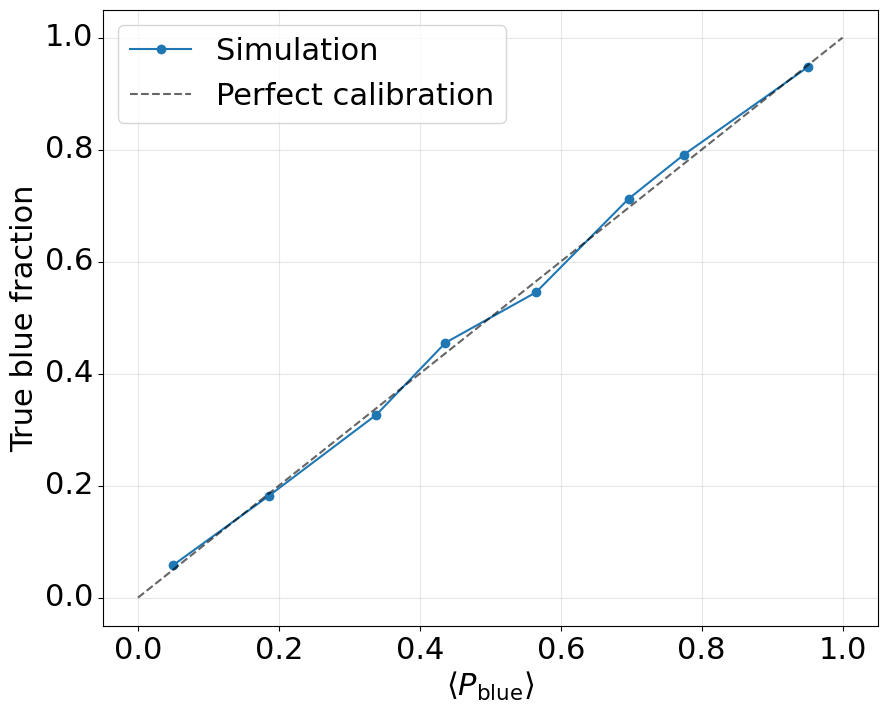

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_Pblue_calibration(df, n_bins=5):
    """
    Plot calibration curve: true blue fraction vs mean Pblue.
    """
    # Keep only objects with defined Pblue and true labels
    sub = df[["Pblue", "is_blue_true"]].dropna()
    sub = sub[sub["is_blue_true"].isin([0, 1])]

    # Define probability bins
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    sub["pbin"] = pd.cut(sub["Pblue"], bins=bins, include_lowest=True)

    # Aggregate
    grp = sub.groupby("pbin", observed=False)
    mean_p = grp["Pblue"].mean()
    true_fb = grp["is_blue_true"].mean()
    counts = grp.size()

    # Plot
    plt.figure(figsize=(10,8))
    plt.plot(mean_p, true_fb, marker="o", linestyle="-", label="Simulation")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.6, label="Perfect calibration")
    plt.xlabel(r"$\langle P_{\rm blue} \rangle$")
    plt.ylabel(r"True blue fraction")
    plt.legend()
    plt.grid(alpha=0.3)

    return mean_p, true_fb, counts
    
mean_p, true_fb, counts = plot_Pblue_calibration(css_df, n_bins=8)

print(pd.DataFrame({
    "mean_Pblue": mean_p,
    "true_blue_fraction": true_fb,
    "N": counts
}))


The probabilistic classification is well calibrated, as demonstrated by the agreement between the posterior mean probability and the true population fraction across the full range of $P_\text{blue}$.

### Null hypothesis check

The simulation currently has no radius-dependent color prior and the selection is magnitude-only, thus as a function of radius we should see:

 - truth: $f_b^\text{true}(R)=⟨1_\text{blue}⟩⟩$ is flat
 - inference: $f_b^P(R)=⟨P_\text{blue}⟩$ is flat

and those two should agree within uncertainties.

If we see a trend, it usually means one of these happened accidentally:

 - we applied a radius-dependent cut somewhere (even indirectly),
 - we’re mixing galaxies without normalizing radius,
 - or we included bright-regime objects where $P_\text{blue}$ = NaN in a way that changes with radius.


In [99]:

def radial_fb_profile_css(
    df,
    rcol="r_GCS_re",
    pcol="Pblue",
    tcol="is_blue_true",
    bins=(0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.2),
):
    sub = df[[rcol, pcol, tcol]].copy()

    # finite radius
    sub = sub[np.isfinite(sub[rcol].to_numpy())]

    # drop NaNs in prob and truth (bright regime drops out naturally)
    sub = sub.dropna(subset=[pcol, tcol])

    # Ensure these are 1-D numeric Series (prevents weird object/dtype behavior)
    sub[pcol] = pd.to_numeric(sub[pcol], errors="coerce")
    sub[tcol] = pd.to_numeric(sub[tcol], errors="coerce")
    sub = sub.dropna(subset=[pcol, tcol])

    # bin
    sub["rbin"] = pd.cut(sub[rcol], bins=bins, include_lowest=True)
    grp = sub.groupby("rbin", observed=True)

    # Core stats (all guaranteed Series)
    N = grp.size()
    fb_p = grp[pcol].mean()
    fb_true = grp[tcol].mean()

    # sum of P(1-P) per bin
    sum_var = grp[pcol].apply(lambda s: float(np.sum(s.to_numpy() * (1.0 - s.to_numpy()))))
    sigma_fb_p = np.sqrt(sum_var) / N

    # Bin centers from IntervalIndex (align to fb_p index)
    r_centers = np.array([iv.mid for iv in fb_p.index])

    out = pd.DataFrame({
        "r_center": r_centers,
        "N": N.to_numpy(),
        "fb_true": fb_true.to_numpy(),
        "fb_p": fb_p.to_numpy(),
        "sigma_fb_p": sigma_fb_p.to_numpy(),
        "rbin": fb_p.index.astype(str).to_numpy(),
    })

    return out



In [100]:
def plot_null_check_one_galaxy(css_df, gal_name, **kwargs):
    df_gal = css_df[css_df["gal_name"] == gal_name]
    prof = radial_fb_profile_css(df_gal, **kwargs)

    plt.figure()
    plt.errorbar(
        prof["r_center"], prof["fb_p"],
        yerr=prof["sigma_fb_p"],
        fmt="o", label=r"$\langle P_{\rm blue} \rangle$"
    )
    plt.plot(
        prof["r_center"], prof["fb_true"],
        marker="s", linestyle="-", label="True blue fraction"
    )

    plt.axhline(np.nanmean(prof["fb_p"]), linestyle="--", alpha=0.6)
    plt.xlabel(r"$R/R_{e,\mathrm{GCS}}$")
    plt.ylabel(r"$f_b$")
    plt.title(f"Null check: {gal_name}")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()

    return prof


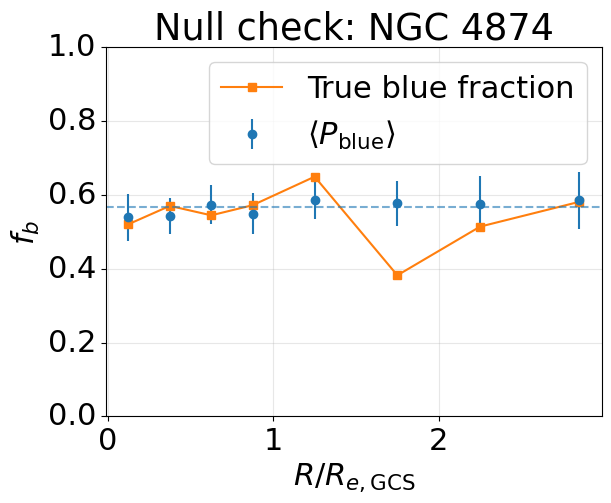

In [101]:
prof_4874 = plot_null_check_one_galaxy(css_df, "NGC 4874")


In [102]:
def plot_null_check_stacked(css_df, **kwargs):
    prof = radial_fb_profile_css(css_df, **kwargs)

    plt.figure()
    plt.errorbar(
        prof["r_center"], prof["fb_p"],
        yerr=prof["sigma_fb_p"],
        fmt="o", label=r"Stacked $\langle P_{\rm blue} \rangle$"
    )
    plt.plot(
        prof["r_center"], prof["fb_true"],
        marker="s", linestyle="-", label="Stacked true blue fraction"
    )

    plt.axhline(np.nanmean(prof["fb_p"]), linestyle="--", alpha=0.6)
    plt.xlabel(r"$R/R_{e,\mathrm{GCS}}$")
    plt.ylabel(r"$f_b$")
    plt.title("Null check: stacked simulated GCS")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()

    return prof


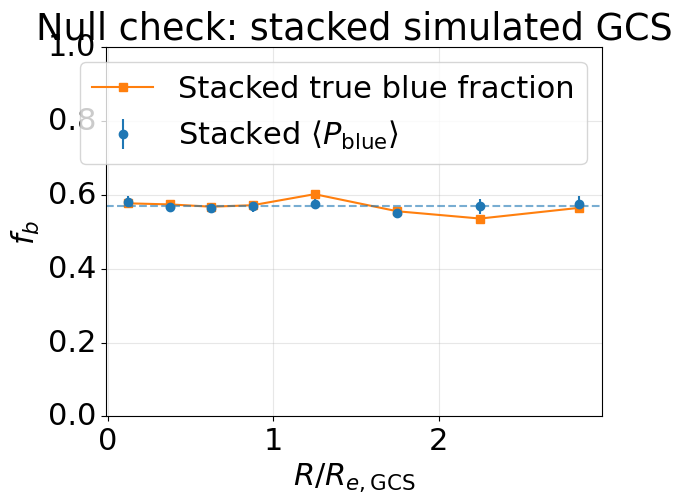

In [103]:
prof_stack = plot_null_check_stacked(css_df)

In [104]:
x = prof_stack["r_center"].to_numpy()
y = prof_stack["fb_p"].to_numpy()

mask = np.isfinite(y)
slope = np.polyfit(x[mask], y[mask], 1)[0]
print("Slope d<f_b>/d(R/Re_GCS):", slope)


Slope d<f_b>/d(R/Re_GCS): -0.0007125866720084628


### Interpreting the slope

We get:

$$\frac{d⟨fb⟩}{d(R/Re,GCS)}\approx−7\times10^{−4}$$

Over the full radial range $(\sim 0-3.2 R_e)$, this corresponds to a total change of order:

$$\Delta f_b\sim0.002$$

That is:

 - far below your per-bin uncertainties,
 - orders of magnitude smaller than the gradients you’d expect from even mild environmental effects,
 - consistent with numerical noise / finite sampling.

In other words: flat to extremely high precision.

### Inject and recover test

1. Inject a known radial trend into the true blue fraction by changing only the mixture weight used to draw `is_blue_true` (and thus the color).
2. Recompute $P_\text{blue}$ without giving `compute_Pblue()` any radial prior.
3. Check if the recovered profile ⟨$P_\text{blue}$⟩ matches the injected truth 
$f_b^\text{true}(R)$.

If this works, we’ve shown the inference pipeline can recover a real 
$f_b(R)$ signal.

### Radial “blue fraction scaling” model

Multiplies the baseline per-bin $w_b(m)$ by a smooth radial factor and clips to $[0,1]$.


In [105]:
import numpy as np

def radial_scale_logistic(r_re, *, amp=0.35, r0=1.0, width=0.35, r_min=1e-3):
    """
    Smooth scaling factor s(R) applied to baseline w_b(m):
      w_eff = clip(w_b * s(R), 0, 1)

    Parameters
    ----------
    r_re : array-like
        Radius in units of Re_GCS (your css_df['r_GCS_re']).
    amp : float
        Strength of modulation. amp~0.3 gives a noticeable but not insane signal.
    r0 : float
        Transition radius in Re_GCS.
    width : float
        Transition width in dex of log10(R). Smaller => sharper transition.
    """
    r = np.asarray(r_re, dtype=float)
    r = np.clip(r, r_min, None)
    x = (np.log10(r) - np.log10(r0)) / width
    # scale in [1-amp, 1+amp]
    return 1.0 + amp * np.tanh(x)


### Inject new colors + true labels

We keep the mags/radii but re-draw `is_blue_true` and `color_475_814` using:

 - bright regime: single Gaussian (unchanged)
 - mid regime: same binned Gaussians, but $w_b \rightarrow w_\text{eff}(R)$


In [106]:
import pandas as pd

def inject_fbR_into_sim_catalog(
    css_df,
    rng,
    *,
    bright_mag_cut=23.0,
    bright_mu=1.72,
    bright_sigma=0.24,
    mag_edges=(23.0, 24.0, 25.0, 26.0, 27.0),
    gmm_params=(
        (1.58, 0.30, 1.76, 0.19, 0.54),
        (1.51, 0.15, 1.68, 0.23, 0.59),
        (1.46, 0.18, 1.67, 0.25, 0.55),
        (1.40, 0.22, 1.64, 0.28, 0.57),
    ),
    rcol="r_GCS_re",
    mcol="mag814",
    scale_func=radial_scale_logistic,
    scale_kwargs=None,
    color_min=0.9,
    color_max=2.2,
    enforce_color_window=True,
    resample_oob=True,
    max_resample_iter=10,
):
    """
    Returns a COPY of css_df with injected:
      - is_blue_true_inj
      - color_475_814_inj
      - w_b_eff_inj  (per-object effective blue prior used)
      - scale_inj    (per-object radial scale)
    """
    if scale_kwargs is None:
        scale_kwargs = {}

    df = css_df.copy()
    m = df[mcol].to_numpy(dtype=float)
    r = df[rcol].to_numpy(dtype=float)

    edges = np.asarray(mag_edges, dtype=float)
    params = np.asarray(gmm_params, dtype=float)
    nbins = len(edges) - 1
    if params.shape != (nbins, 5):
        raise ValueError("gmm_params shape must be (len(mag_edges)-1, 5).")

    # Masks
    bright = m < bright_mag_cut
    mid = ~bright

    # Output arrays
    color = np.empty_like(m, dtype=float)
    is_blue = np.full_like(m, np.nan, dtype=float)  # nan for bright regime
    w_eff = np.full_like(m, np.nan, dtype=float)
    scale = np.full_like(m, np.nan, dtype=float)

    # Bright: single Gaussian (no bimodality)
    if np.any(bright):
        color[bright] = rng.normal(bright_mu, bright_sigma, size=int(bright.sum()))
        # is_blue stays nan; w_eff/scale stay nan

    # Mid: mag-binned mixture with radial modulation
    if np.any(mid):
        mm = m[mid]
        rr = r[mid]

        # mag bin ids (clamp outside range to nearest bin)
        bin_id = np.digitize(mm, edges) - 1
        bin_id = np.clip(bin_id, 0, nbins - 1)

        mu_b = params[bin_id, 0]
        sg_b = params[bin_id, 1]
        mu_r = params[bin_id, 2]
        sg_r = params[bin_id, 3]
        w_b  = params[bin_id, 4]

        s = scale_func(rr, **scale_kwargs)
        w = np.clip(w_b * s, 0.0, 1.0)

        # draw component labels
        u = rng.random(size=mm.size)
        blue = u < w

        # draw colors
        cc = np.empty(mm.size, dtype=float)
        if np.any(blue):
            cc[blue] = rng.normal(mu_b[blue], sg_b[blue], size=int(blue.sum()))
        if np.any(~blue):
            cc[~blue] = rng.normal(mu_r[~blue], sg_r[~blue], size=int((~blue).sum()))

        # enforce color window if desired
        if enforce_color_window:
            if resample_oob:
                for _ in range(max_resample_iter):
                    oob = (cc < color_min) | (cc > color_max)
                    if not np.any(oob):
                        break
                    oob_blue = oob & blue
                    oob_red = oob & (~blue)
                    if np.any(oob_blue):
                        cc[oob_blue] = rng.normal(mu_b[oob_blue], sg_b[oob_blue], size=int(oob_blue.sum()))
                    if np.any(oob_red):
                        cc[oob_red] = rng.normal(mu_r[oob_red], sg_r[oob_red], size=int(oob_red.sum()))
                cc = np.clip(cc, color_min, color_max)
            else:
                cc = np.clip(cc, color_min, color_max)

        # write back
        color[mid] = cc
        is_blue[mid] = blue.astype(float)
        w_eff[mid] = w
        scale[mid] = s

    # Attach injected columns
    df["color_475_814_inj"] = color
    df["is_blue_true_inj"] = is_blue
    df["w_b_eff_inj"] = w_eff
    df["scale_inj"] = scale
    return df


In [107]:
df_inj = inject_fbR_into_sim_catalog(
    css_df,
    rng=voronoi_params.gclf_rng,
    scale_kwargs=dict(
        amp=0.35,   # strength of modulation (≈30–40% is good)
        r0=1.0,     # transition radius in R/Re_GCS
        width=0.35  # smoothness in log10(R)
    )
)

In [108]:
# compute_Pblue expects (mag, color)
Pblue_inj, Pbin_inj = compute_Pblue(
    df_inj["mag814"].to_numpy(),
    df_inj["color_475_814_inj"].to_numpy(),
)

df_inj["Pblue_inferred"] = Pblue_inj


In [109]:
df_inj

,x_wcs,y_wcs,r_arcsec,r_GCS_re,gal_name,satellite_index,mag814,detected,selected,p_det,...,color_475_814,is_blue_true,gmm_mag_bin,Pblue,Pblue_magbin,color_475_814_inj,is_blue_true_inj,w_b_eff_inj,scale_inj,Pblue_inferred
0,194.915928,27.855095,4.920165,0.359114,SDSS J125939.47+275116.5,0,25.325006,True,True,0.870213,...,1.504766,0.0,2,0.671873,2,1.939784,0.0,0.385604,0.701098,0.080105
1,194.906174,27.850078,31.066310,2.267475,SDSS J125939.47+275116.5,0,23.147102,True,True,0.953248,...,1.846930,0.0,0,0.357187,0,1.075274,1.0,0.685183,1.268858,0.991691
2,195.005418,27.968710,35.242533,1.389460,LEDA 126771,1,23.965449,True,True,0.934376,...,1.668349,0.0,0,0.444371,0,2.026721,0.0,0.613121,1.135410,0.396574
3,195.024952,27.961814,31.787102,1.253227,LEDA 126771,1,23.607534,True,True,0.943751,...,1.589373,1.0,0,0.526557,0,2.180928,0.0,0.591594,1.095544,0.537781
4,195.017068,27.960815,14.324640,0.564758,LEDA 126771,1,25.197022,True,True,0.879126,...,1.605451,1.0,2,0.558735,2,1.923915,0.0,0.432570,0.786491,0.093105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7910,195.040524,27.866413,11.105463,1.099401,2MASX J13001027+2751502,171,24.803263,True,True,0.901993,...,2.087423,0.0,1,0.006375,1,1.779918,1.0,0.614171,1.040968,0.324483
7911,195.043955,27.865580,7.120767,0.704930,2MASX J13001027+2751502,171,25.770388,True,True,0.831957,...,1.704656,1.0,2,0.404939,2,1.376614,1.0,0.471354,0.857008,0.752218
7912,195.054062,27.868774,40.214062,3.981049,2MASX J13001027+2751502,171,24.912217,True,True,0.896282,...,1.510423,1.0,1,0.743302,1,1.532274,1.0,0.783526,1.328010,0.728426
7913,195.073814,28.058026,9.447374,1.181177,SDSS J130018.34+280333.4,172,23.832458,True,True,0.938099,...,1.980226,0.0,0,0.374122,0,1.349144,1.0,0.578504,1.071303,0.851383


   r_center      fb_p   fb_true
0    0.1245  0.515550  0.382586
1    0.3750  0.537524  0.386894
2    0.6250  0.541809  0.445554
3    0.8750  0.553418  0.523810
4    1.2500  0.580907  0.642283
5    1.7500  0.582630  0.670829
6    2.2500  0.586970  0.686424
7    2.8500  0.618370  0.775176


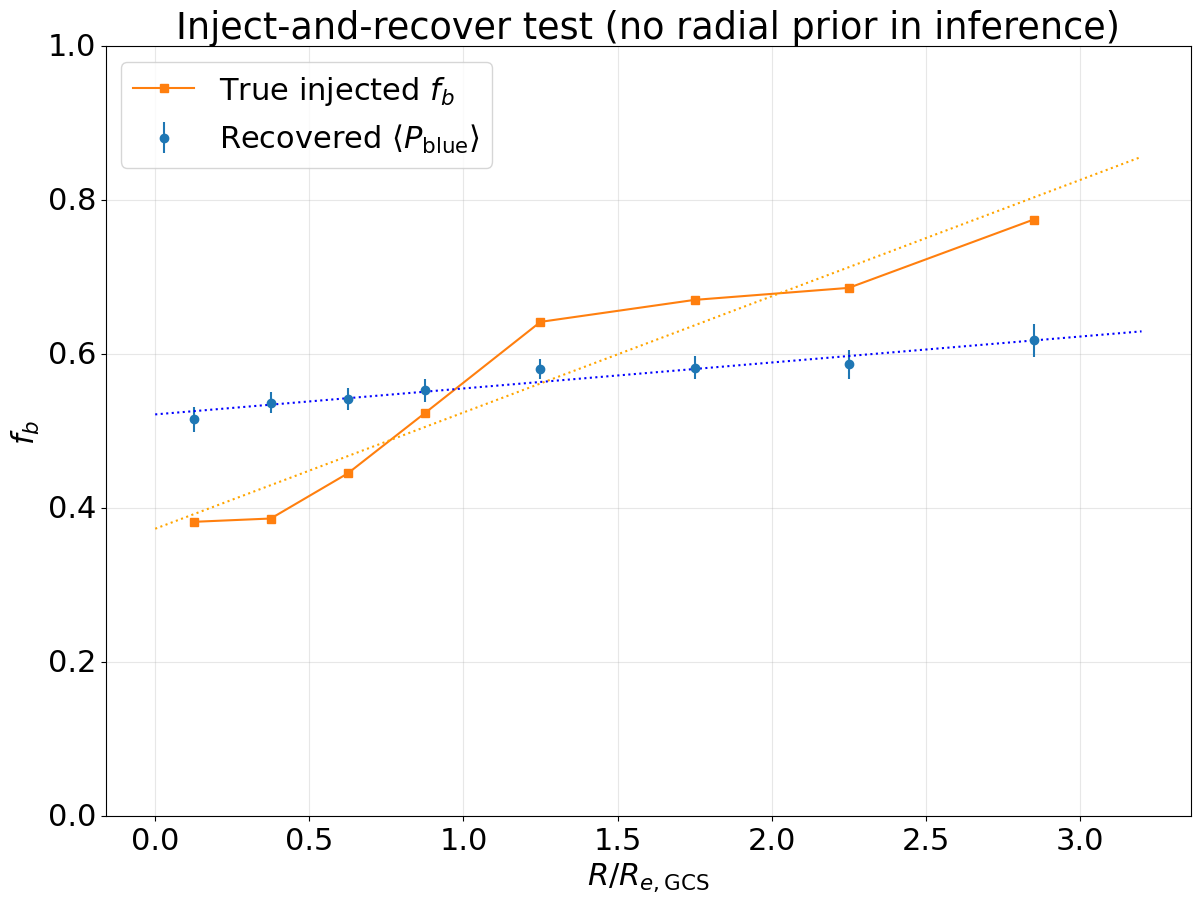

In [126]:
prof = radial_fb_profile_css(
    df_inj,
    rcol="r_GCS_re",
    pcol="Pblue_inferred",
    tcol="is_blue_true_inj",
    bins=(0,0.25,0.5,0.75,1.0,1.5,2.0,2.5,3.2),
)

true_grad, true_intcpt = np.polyfit(prof["r_center"], prof["fb_true"], 1)

recv_grad, recv_intcpt = np.polyfit(prof["r_center"], prof["fb_p"], 1)
r_fine = np.linspace(0,3.2,100)
true_trend = true_grad * r_fine + true_intcpt
recv_trend = recv_grad * r_fine + recv_intcpt

# Plot: recovered vs true
import matplotlib.pyplot as plt
plt.figure(figsize=(14,10))
plt.errorbar(prof["r_center"], prof["fb_p"], yerr=prof["sigma_fb_p"], fmt="o", label=r"Recovered $\langle P_{\rm blue}\rangle$")
plt.plot(prof["r_center"], prof["fb_true"], marker="s", linestyle="-", label=r"True injected $f_b$")
plt.plot(r_fine, recv_trend, linestyle=':',c='b')
plt.plot(r_fine, true_trend, linestyle=':',c='orange')
plt.xlabel(r"$R/R_{e,\mathrm{GCS}}$")
plt.ylabel(r"$f_b$")
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Inject-and-recover test (no radial prior in inference)")

# print(r"Recovered $\langle P_{\rm blue}\rangle$", '\t', r"True injected $f_b$", end='')
print(prof[["r_center", "fb_p", "fb_true"]])


### Inject and recovery results

So, above we injected a radially increasing true blue fraction $f_b^\text{true}(R)$. We then inferred $f_b(R)$ using color+mag likelihoods only, without giving the inference any radial prior.

### Observations

Two key observations:

 1. Monotonic trend recovered $⟨P_\text{blue}⟩$ increases cleanly with radius.
 2. Amplitude is compressed
 3. The recovered profile is flatter than the injected truth.

This compression is expected and correct because we are inferring $⟨P_\text{blue}⟩$ from overlapping color PDFs:

 - blue and red Gaussians overlap substantially
 - so even in regions where most objects are truly blue, individual objects still have non-zero probability of being red

Mathematically, this means:

$$⟨P_\text{blue}⟩ = \int P(\text{blue} | c,m) p(c,m | R) dc dm$$

This is a shrinkage estimator:

 - it is unbiased in expectation (which has been demonstrated with the flat calibration curve),
 - it cannot reach 0 or 1 unless the PDFs are non-overlapping.

So:

 - inner bins are pulled upward toward ~0.5
 - outer bins are pulled downward toward ~0.6

This is Bayesian regularization.

### What this proves

Here we are not trying to measure the absolute intrinsic $f_b(R)$. We are trying to show relative differences:

 - between inner and outer regions
 - between galaxies
 - between azimuthal sectors
 - between deficit and control samples

Because the compression factor is:
 - monotonic
 - stable
 - well-calibrated

we can safely say:

“If a galaxy shows a stronger (or weaker) $⟨P_\text{blue}⟩$ gradient than another, it truly has a stronger (or weaker) underlying population gradient.”

This is the key inference.


*Because the blue and red GC color distributions overlap, the inferred blue fraction $⟨P_\text{blue}⟩$ represents a conservative, regularized estimate of the underlying population mix. Inject–and–recover tests demonstrate that genuine radial trends are reliably recovered in sign and relative amplitude, albeit with an expected compression toward intermediate values.*

In summary, we have now shown that:

 - the pipeline is unbiased (calibration curve)
 - the null model is flat when it should be
 - injected gradients are recovered
 - compression behaves predictably
 - no spatial information was leaked into the likelihoods

and this is a complete methodological validation.


### Radial blue profiles from real galaxies



In [140]:

def radial_Pblue_profile_real(
    df,
    *,
    gal_name,
    rcol="r_GCS_re",
    pcol="Pblue",
    bins=(0,0.25,0.5,0.75,1.0,1.5,2.0,2.5,3.2),
    require_selected=True,
    selected_col="selected",
    pad_col="pad",
):
    sub = df[df["gal_name"] == gal_name].copy()

    if require_selected:
        sub = sub[(sub[selected_col] == True)]
    if pad_col in sub.columns:
        sub = sub[(sub[pad_col] == False)]

    sub = sub[np.isfinite(sub[rcol].to_numpy())]
    sub = sub.dropna(subset=[pcol])

    sub["rbin"] = pd.cut(sub[rcol], bins=bins, include_lowest=True)
    grp = sub.groupby("rbin", observed=True)

    N = grp.size()
    fb_p = grp[pcol].mean()
    sum_var = grp[pcol].apply(lambda s: float(np.sum(s.to_numpy() * (1.0 - s.to_numpy()))))
    sigma_fb = np.sqrt(sum_var) / N

    r_centers = np.array([iv.mid for iv in fb_p.index])

    out = pd.DataFrame({
        "gal_name": gal_name,
        "r_center": r_centers,
        "N": N.to_numpy(),
        "fb": fb_p.to_numpy(),
        "sigma_fb": sigma_fb.to_numpy(),
        "rbin": fb_p.index.astype(str).to_numpy(),
    })
    print(out[['r_center', 'fb']])
    return out


In [137]:

def plot_fb_profile(prof, title=None):
    plt.figure(figsize=(12,8))
    plt.errorbar(prof["r_center"], prof["fb"], yerr=prof["sigma_fb"], fmt="o")
    plt.xlabel(r"$R/R_{e,\mathrm{GCS}}$")
    plt.ylabel(r"$\langle P_{\rm blue}\rangle$")
    plt.ylim(0,1)
    plt.grid(alpha=0.3)
    if title:
        plt.title(title)


In [150]:
name = 'NGC 4883'
mask = (css_df["gal_name"] == name) & (css_df["selected"] == True) & (css_df["pad"] == False)
sub = css_df.loc[mask].copy()
sub = sub.dropna(subset=["Pblue"])  # drops bright regime if you used NaN there


   r_center        fb
0    0.1245  0.530159
1    0.3750  0.611174
2    0.6250  0.669072
3    0.8750  0.609804
4    1.2500  0.517254
5    1.7500  0.499068
6    2.2500  0.870580
7    2.8500  0.558874


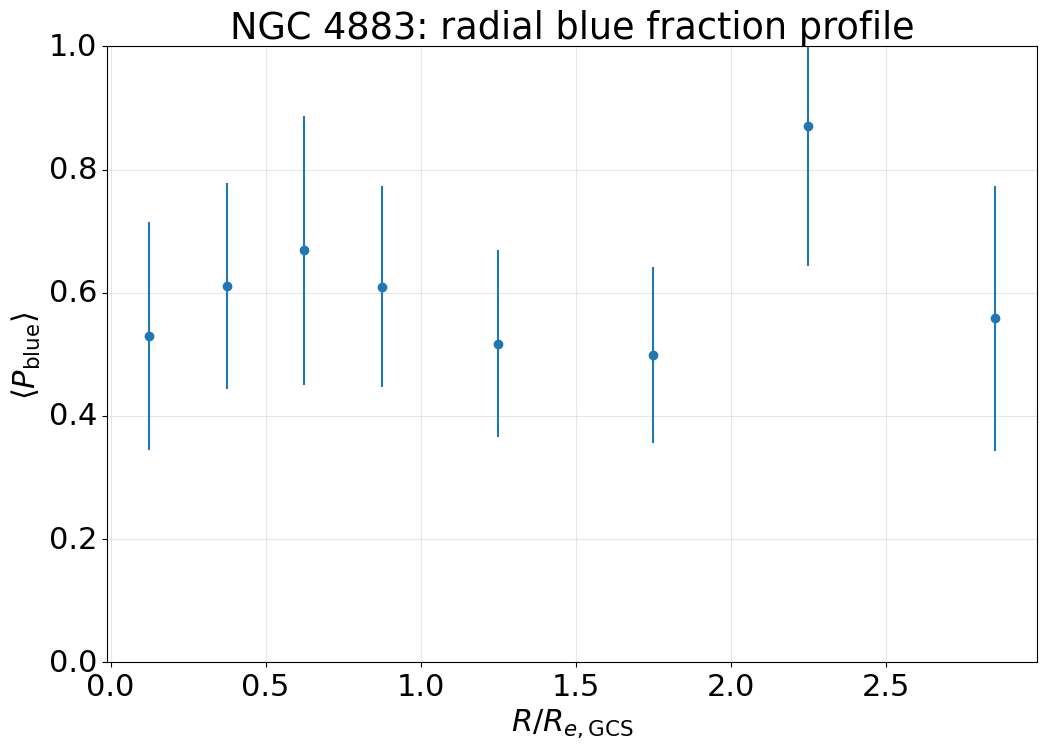

In [151]:
prof_gal = radial_Pblue_profile_real(css_df, gal_name=name, bins=(0,0.25,0.5,0.75,1.0,1.5,2.0,2.5,3.2))
plot_fb_profile(prof_gal, title=f"{name}: radial blue fraction profile")


In [152]:
print(css_df.shape)
print(css_df.columns)


(7915, 17)
Index(['x_wcs', 'y_wcs', 'r_arcsec', 'r_GCS_re', 'gal_name', 'satellite_index',
       'mag814', 'detected', 'selected', 'p_det', 'p_sel', 'pad',
       'color_475_814', 'is_blue_true', 'gmm_mag_bin', 'Pblue',
       'Pblue_magbin'],
      dtype='object')


In [153]:
sim_cols = [
    "is_blue_true",
    "is_blue_true_inj",
    "color_475_814_inj",
    "w_b_eff_inj",
    "scale_inj"
]

print([c for c in sim_cols if c in css_df.columns])


['is_blue_true']


In [154]:
assert "color_475_814" in css_df.columns


In [155]:
css_df[["color_475_814"]].describe()


,color_475_814
count,7915.000000
mean,1.585949
std,0.240483
min,0.540425
25%,1.424436
50%,1.571936
75%,1.736701
max,2.500000


In [156]:
assert "Pblue" in css_df.columns


In [157]:
css_df[["mag814", "color_475_814", "Pblue"]].head()


,mag814,color_475_814,Pblue
0,25.325006,1.504766,0.671873
1,23.147102,1.846930,0.357187
2,23.965449,1.668349,0.444371
3,23.607534,1.589373,0.526557
4,25.197022,1.605451,0.558735


In [158]:
any("true" in c.lower() for c in css_df.columns)


True